In [5]:
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
limites = gpd.read_file(RAW / 'limites_inei' / 'peru_distrital_simple.geojson')

## Parte 0 · Conexión y parámetros

In [1]:
import io
import json
import os
import re
import struct
import time
import zlib
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from databricks.connect import DatabricksSession
from databricks.sdk import WorkspaceClient
from pyspark.sql import functions as F, types as T
from pyspark.sql.window import Window

# ---------------- Databricks ----------------
PROFILE = "22200144"                  # perfil de ~/.databrickscfg (el mismo de PcPractica)
CATALOG = "Grupo06ProyectoFinal"      # Unity Catalog lo guarda en minúsculas: grupo06proyectofinal
BRONZE = "bronze"
SILVER = "silver"
GOLD = "gold"
TANDA = "01"                         # primera tanda de datos
VOLUMEN = f"volumen{TANDA}"           # volumen dentro de bronze: volumen01

# ---------------- Rutas locales (raw se queda en la PC) ----------------
RAIZ = Path.cwd()                     # el notebook está en la raíz del proyecto (junto a raw/)
RAW = RAIZ / "raw"

# Área de estudio
PROVINCIAS_ESTUDIO = ["LIMA", "CALLAO"]       # columna NOMBPROV de los límites INEI
ZONA_E030_LIMA = 4                             # Lima y Callao: Zona 4 (Z = 0.45 g)
EPSG_UTM_LIMA = 32718                          # UTM 18S

spark = DatabricksSession.builder.profile(PROFILE).serverless(True).getOrCreate()
ws = WorkspaceClient(profile=PROFILE)
spark.conf.set("spark.sql.session.timeZone", "America/Lima")
print("Spark:", spark.range(1).count(), "| raw local:", RAW.as_posix(), "| existe:", RAW.exists())

Spark: 1 | raw local: C:/Ciclo09/BigData/ProyectoFinal/raw | existe: True


### Catálogo, esquemas y volumen
- Catálogo `Grupo06ProyectoFinal` con los esquemas `bronze`, `silver` y `gold`.
- Volumen `bronze.volumen01` para la **tanda 01**: guarda el manifiesto de `raw/` (qué archivos, tamaño y fecha). Los archivos crudos no se suben.

In [2]:
spark.sql(f"CREATE CATALOG IF NOT EXISTS `{CATALOG}` COMMENT 'BigData Grupo 06 - Proyecto final: lakehouse sismico de Lima'")
spark.sql(f"CREATE SCHEMA IF NOT EXISTS `{CATALOG}`.`{BRONZE}` COMMENT 'Fuentes tal como llegaron de raw/ (sin limpiar) con columnas de linaje'")
spark.sql(f"CREATE SCHEMA IF NOT EXISTS `{CATALOG}`.`{SILVER}` COMMENT 'Datos limpios, tipados y unidos: ondas, territorio, edificios y validacion'")
spark.sql(f"CREATE SCHEMA IF NOT EXISTS `{CATALOG}`.`{GOLD}` COMMENT 'Tablas analiticas: amplificacion, demanda, dano, rankings y metricas de modelos'")
spark.sql(f"CREATE VOLUME IF NOT EXISTS `{CATALOG}`.`{BRONZE}`.`{VOLUMEN}` "
          f"COMMENT 'Tanda {TANDA}: manifiesto de raw/ (los archivos crudos quedan en la PC)'")
VOLUMEN_PATH = f"/Volumes/{CATALOG.lower()}/{BRONZE}/{VOLUMEN}"
spark.sql(f"SHOW SCHEMAS IN `{CATALOG}`").show(truncate=False)
spark.sql(f"SHOW VOLUMES IN `{CATALOG}`.`{BRONZE}`").show(truncate=False)
print(VOLUMEN_PATH)

+------------------+
|databaseName      |
+------------------+
|bronze            |
|default           |
|gold              |
|information_schema|
|silver            |
+------------------+



+--------+-----------+
|database|volume_name|
+--------+-----------+
|bronze  |volumen01  |
+--------+-----------+

/Volumes/grupo06proyectofinal/bronze/volumen01


### Funciones comunes
| Función | Qué hace |
|---|---|
| `tabla_uc(capa, tabla)` / `leer(capa, tabla)` | Nombre completo `` `catálogo`.`capa`.`tabla` `` y lectura de la tabla Delta |
| `con_metadatos(df, fuente, archivo)` | Columnas de linaje de bronze: `_fuente`, `_archivo`, `_tanda`, `_fecha_ingesta` |
| `escribir_delta(df, capa, tabla)` | Guarda un DataFrame de Spark como tabla Delta (sobrescribe) |
| `subir_pandas(lotes, capa, tabla)` | Sube DataFrames de pandas (leídos en la PC) a una tabla Delta, en lotes de ~64 MB |
| `registrar_calidad(df, tabla)` | Reemplaza en `silver.calidad_log` las filas de `tabla` |
| `unir_poligonos(...)` | Point-in-polygon (`ST_Within`): a cada punto le agrega los atributos del polígono que lo contiene |
| `inventario(capa)` | Tablas de una capa con filas y tamaño |

In [3]:
INICIO = time.perf_counter()
TIEMPOS = []          # (paso, segundos) para el resumen de bronze
def cronometro(paso, t0):
    TIEMPOS.append((paso, round(time.perf_counter() - t0, 1)))


def tabla_uc(capa, tabla):
    return f"`{CATALOG}`.`{capa}`.`{tabla}`"


def leer(capa, tabla):
    return spark.table(tabla_uc(capa, tabla))


def con_metadatos(df, fuente, archivo=None):
    """Agrega el linaje de bronze: _fuente, _archivo, _tanda y _fecha_ingesta.

    archivo=None: el DataFrame ya trae la columna _archivo (ruta local de cada fila en raw/).
    """
    if archivo is not None:
        df = df.withColumn("_archivo", F.lit(str(archivo)))
    return (df.withColumn("_fuente", F.lit(fuente))
              .withColumn("_tanda", F.lit(TANDA))
              .withColumn("_fecha_ingesta", F.current_timestamp()))


def _guardar(df, capa, tabla, modo="overwrite", particion=None):
    escritor = df.write.format("delta").mode(modo)
    if modo == "overwrite":
        escritor = escritor.option("overwriteSchema", "true")
    if particion:
        escritor = escritor.partitionBy(particion)
    escritor.saveAsTable(tabla_uc(capa, tabla))


def escribir_delta(df, capa, tabla, particion=None, modo="overwrite"):
    """Escribe (sobrescribe) una tabla Delta en Unity Catalog y devuelve cuántas filas tiene."""
    _guardar(df, capa, tabla, modo, particion)
    n = leer(capa, tabla).count()
    print(f"  ✓ {capa}.{tabla}: {n:,} filas")
    return n


def a_spark(pdf, esquema=None):
    """pandas (PC) -> DataFrame de Spark (viaja a Databricks por Arrow).

    En columnas object: NaN -> None y valores sueltos (números, fechas) a texto, para que Arrow no falle con tipos mezclados.
    pandas 3 guarda el texto como cadenas de Arrow (a veces en varios trozos, p. ej. tras un concat) y PySpark no las
    acepta: se pasan a object antes.
    """
    pdf = pdf.copy()
    for c in pdf.columns:
        if isinstance(pdf[c].dtype, (pd.StringDtype, pd.ArrowDtype)):
            pdf[c] = pdf[c].astype(object)
        if pdf[c].dtype == object:
            pdf[c] = pdf[c].map(lambda v: v if v is None or isinstance(v, (str, bytes, list, dict, np.ndarray))
                                else (None if pd.isna(v) else str(v)))
    return spark.createDataFrame(pdf, esquema) if esquema is not None else spark.createDataFrame(pdf)


def subir_pandas(lotes, capa, tabla, esquema=None, preparar=None, particion=None, mb_lote=64):
    """Sube uno o varios DataFrames de pandas a una tabla Delta, partidos en lotes de ~mb_lote MB.

    El primer lote sobrescribe la tabla y los demás se agregan (append). `lotes` puede ser un DataFrame o un
    iterador de DataFrames (p. ej. un CSV grande leído por partes). `preparar(df_spark)` agrega columnas (linaje).
    """
    if isinstance(lotes, pd.DataFrame):
        lotes = [lotes]
    modo, n_lotes, filas = "overwrite", 0, 0
    for pdf in lotes:
        if len(pdf) == 0:
            continue
        partes = max(1, int(np.ceil(pdf.memory_usage(deep=True).sum() / 1e6 / mb_lote)))
        for idx in np.array_split(np.arange(len(pdf)), partes):
            sdf = a_spark(pdf.iloc[idx], esquema)
            if preparar is not None:
                sdf = preparar(sdf)
            _guardar(sdf, capa, tabla, modo, particion)
            modo, n_lotes, filas = "append", n_lotes + 1, filas + len(idx)
            if n_lotes > 1:
                print(f"    lote {n_lotes}: {filas:,} filas subidas", end="\r")
    n = leer(capa, tabla).count()
    print(f"  ✓ {capa}.{tabla}: {n:,} filas ({n_lotes} lote{'s' if n_lotes != 1 else ''})" + " " * 20)
    return n


# ---------------- calidad_log ----------------
# Cada fila descartada, imputada o con advertencia queda registrada. Para descartes masivos que no son
# errores (p. ej. edificios fuera de Lima) se guarda una fila agregada con n_filas.
ESQUEMA_PROBLEMAS = "fuente string, regla string, accion string, registro_id string, detalle string, n_filas long"


def registrar_calidad(df_problemas, tabla):
    """Reemplaza en silver.calidad_log las filas de `tabla` por df_problemas (re-ejecutar no duplica).

    df_problemas debe tener: fuente, regla, accion, registro_id, detalle, n_filas.
    """
    df = (df_problemas
          .withColumn("tabla", F.lit(tabla))
          .withColumn("fecha", F.current_timestamp())
          .select("fuente", "tabla", "regla", "accion", "registro_id", "detalle",
                  F.col("n_filas").cast("long").alias("n_filas"), "fecha"))
    if spark.catalog.tableExists(f"{CATALOG}.{SILVER}.calidad_log"):
        (df.write.format("delta").mode("overwrite")
           .option("replaceWhere", f"tabla = '{tabla}'").saveAsTable(tabla_uc(SILVER, "calidad_log")))
    else:
        df.write.format("delta").mode("overwrite").partitionBy("tabla").saveAsTable(tabla_uc(SILVER, "calidad_log"))
    resumen = (leer(SILVER, "calidad_log").where(F.col("tabla") == tabla)
               .groupBy("regla", "accion").agg(F.sum("n_filas").alias("filas")).orderBy(F.desc("filas")).collect())
    for r in resumen:
        print(f"  calidad_log [{tabla}] {r['accion']:<11} {r['regla']}: {r['filas']:,}")


def problemas(filas):
    """DataFrame de calidad desde una lista de dicts (para registros agregados)."""
    pdf = pd.DataFrame(filas, columns=["fuente", "regla", "accion", "registro_id", "detalle", "n_filas"])
    pdf["n_filas"] = pdf["n_filas"].astype("int64")
    return a_spark(pdf, ESQUEMA_PROBLEMAS)


def inventario(capa):
    """Tablas de una capa con su número de filas y tamaño (DESCRIBE DETAIL)."""
    filas = []
    for t in spark.sql(f"SHOW TABLES IN `{CATALOG}`.`{capa}`").collect():
        if t.isTemporary:
            continue
        d = spark.sql(f"DESCRIBE DETAIL {tabla_uc(capa, t.tableName)}").first()
        filas.append({"tabla": f"{capa}.{t.tableName}", "filas": leer(capa, t.tableName).count(),
                      "mb": round((d["sizeInBytes"] or 0) / 1e6, 1)})
    return pd.DataFrame(filas)

### Funciones espaciales de Databricks
Se prueba si el workspace tiene las funciones `ST_*` (geometría) y H3 nativas. Las `ST_*` reemplazan a Apache Sedona para el point-in-polygon; si no están, `unir_poligonos` lo resuelve en la PC con Shapely (STRtree) y sube el resultado.

In [4]:
import shapely

try:
    spark.sql("SELECT st_contains(st_geomfromwkt('POLYGON((0 0,1 0,1 1,0 1,0 0))', 4326), st_point(0.5, 0.5, 4326)) AS ok").first()
    USAR_ST = True
except Exception as e:
    USAR_ST = False
    print("Funciones ST_* no disponibles:", str(e).splitlines()[0][:150])
print("Point-in-polygon con:", "funciones ST_* de Databricks" if USAR_ST else "Shapely en local (fallback)")
spark.sql("SELECT h3_longlatash3string(-77.0428, -12.0464, 9) AS h3_r9, h3_toparent(h3_longlatash3string(-77.0428, -12.0464, 9), 8) AS h3_r8").show()


def unir_poligonos(puntos, poligonos, atributos, clave, lon="lon", lat="lat"):
    """Agrega a `puntos` (Spark) los `atributos` del polígono que contiene cada punto (equivalente a ST_Within).

    poligonos: pandas con las columnas `atributos` + `geometry_wkt` (WGS84). clave: columnas que identifican cada punto.
    Puntos fuera de todos los polígonos quedan con nulos; un punto en el borde de dos polígonos se queda con el primero.
    """
    pol = poligonos[atributos + ["geometry_wkt"]].rename(columns={"geometry_wkt": "_pol_wkt"})
    sin_geometria = pol["_pol_wkt"].isna()            # en pandas 3 una geometría faltante llega como NaN (no None)
    if sin_geometria.any():
        print(f"  unir_poligonos: {sin_geometria.sum()} polígono(s) sin geometría se omiten:",
              pol.loc[sin_geometria, atributos].to_dict("records"))
    pol = pol[~sin_geometria].reset_index(drop=True)
    pol["_pol_wkt"] = pol["_pol_wkt"].astype(object)
    pol["_pid"] = np.arange(len(pol))
    geoms = shapely.from_wkt(pol["_pol_wkt"].to_numpy())
    pts = puntos.select(*clave, F.col(lon).alias("_lon"), F.col(lat).alias("_lat"))
    if USAR_ST:
        pol["_xmin"], pol["_ymin"], pol["_xmax"], pol["_ymax"] = shapely.bounds(geoms).T
        cond = (F.col("_lon").between(F.col("_xmin"), F.col("_xmax")) & F.col("_lat").between(F.col("_ymin"), F.col("_ymax"))
                & F.expr("st_contains(st_geomfromwkt(_pol_wkt, 4326), st_point(_lon, _lat, 4326))"))
        cruces = pts.join(F.broadcast(a_spark(pol)), cond, "inner").select(*clave, "_pid", *atributos)
    else:
        pdf = pts.toPandas()
        i_pt, i_pol = shapely.STRtree(geoms).query(shapely.points(pdf["_lon"].to_numpy(), pdf["_lat"].to_numpy()),
                                                   predicate="within")
        cr = pdf.iloc[i_pt][clave].reset_index(drop=True)
        cr["_pid"] = i_pol
        cr = cr.join(pol.loc[i_pol, atributos].reset_index(drop=True))
        cruces = a_spark(cr)
    primero = Window.partitionBy(*clave).orderBy("_pid")
    cruces = cruces.withColumn("_r", F.row_number().over(primero)).where("_r = 1").drop("_r", "_pid")
    return puntos.join(cruces, clave, "left")

Point-in-polygon con: funciones ST_* de Databricks


+---------------+---------------+
|          h3_r9|          h3_r8|
+---------------+---------------+
|898e62c0cdbffff|888e62c0cdfffff|
+---------------+---------------+



# Parte 1 · Bronze — ingesta de las fuentes

Cada fuente de `raw/` se lee **en la PC** y se sube **tal como llegó** a una tabla Delta de `Grupo06ProyectoFinal.bronze`, con cuatro columnas de linaje:

| Columna | Contenido |
|---|---|
| `_fuente` | nombre de la fuente (cismid, vs30, open_buildings…) |
| `_archivo` | archivo de `raw/` (en la PC) del que sale cada fila |
| `_tanda` | tanda de datos (`01`) |
| `_fecha_ingesta` | momento de la carga |

De las **imágenes y rásters pesados** (xBD, Maxar, alturas 2.5D, HDF5 de STEAD) solo se suben **rutas y metadatos**; los píxeles se leen en la PC cuando silver los necesita.

| # | Fuente | Formato en raw | Tabla(s) bronze |
|---|---|---|---|
| 1 | CISMID (137 registros, 5 sismos) | texto | `cismid_registros` |
| 2 | Vs30 USGS | ráster netCDF | `vs30_pixeles` |
| 3 | Microzonificación (4 distritos) | PDF | `microzonificacion_paginas` |
| 4 | Open Buildings v3 | CSV | `open_buildings` |
| 5 | Open Buildings 2.5D (altura) | GeoTIFF | `open_buildings_25d_teselas` |
| 6 | Límites INEI | GeoJSON | `limites_inei` |
| 7 | xBD | Parquet + imágenes | `xbd_indice` |
| 8 | Maxar Turquía | TSV + GeoTIFF | `maxar_catalogo`, `maxar_imagenes` |
| 9 | ShakeMap Turquía | XML | `shakemap_grid` |
| 10 | STEAD | ZIP (HDF5 + CSV) | `stead_metadata` |
| 11 | Norma E.030 | CSV | `e030_zonas`, `e030_factor_suelo`, `e030_perfiles` |
| – | SMD-TR (opcional) | CSV | `smdtr_*` si existe en raw |

## 1. CISMID — acelerogramas de Lima
Cada `.txt` es un registro (una estación en un sismo): una fila por archivo con el texto íntegro (cabecera + aceleraciones). El evento sale del nombre de la carpeta.

Los archivos se leen como **bytes** y se decodifican uno por uno: casi todos están en UTF-8, pero algunos de 2007 vienen en **Latin-1** (ISO-8859-1). La codificación original queda en la columna `codificacion`.

In [5]:
def _decodificar(datos):
    try:
        return datos.decode("utf-8"), "utf-8"
    except UnicodeDecodeError:
        return datos.decode("latin-1"), "latin-1"


t0 = time.perf_counter()
filas = []
for txt in sorted(RAW.glob("cismid/*/*.txt")):
    contenido, codificacion = _decodificar(txt.read_bytes())
    filas.append({"evento": txt.parent.name, "archivo_estacion": txt.stem, "bytes": txt.stat().st_size,
                  "codificacion": codificacion, "contenido": contenido, "_archivo": txt.as_posix()})
subir_pandas(pd.DataFrame(filas), BRONZE, "cismid_registros",
             esquema="evento string, archivo_estacion string, bytes long, codificacion string, contenido string, _archivo string",
             preparar=lambda df: con_metadatos(df, "cismid"))
cronometro("cismid_registros", t0)
leer(BRONZE, "cismid_registros").groupBy("evento", "codificacion").count().orderBy("evento").show(truncate=False)

  ✓ bronze.cismid_registros: 137 filas (4 lotes)                    
+------------------------+------------+-----+
|evento                  |codificacion|count|
+------------------------+------------+-----+
|2007-08-15_pisco_Mw7.9  |utf-8       |1    |
|2007-08-15_pisco_Mw7.9  |latin-1     |2    |
|2021-11-28_callao_O_M5.2|utf-8       |32   |
|2022-01-07_lima_NE_M5.6 |utf-8       |32   |
|2025-06-15_callao_M6.1  |utf-8       |32   |
|2026-05-19_ica_M6.1     |utf-8       |38   |
+------------------------+------------+-----+



## 2. Vs30 (USGS) — píxeles del área de estudio
El mosaico global (`global_vs30.grd`, 43201 × 16801 px a 30") no se sube entero: se guardan los píxeles del rectángulo que contiene a Lima y Callao (+0.05° de margen), con su fila/columna en la grilla global para poder unirlos después por clave.

In [6]:
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds

t0 = time.perf_counter()
limites = gpd.read_file(RAW / "limites_inei" / "peru_distrital_simple.geojson")
x0, y0, x1, y1 = limites[limites.NOMBPROV.isin(PROVINCIAS_ESTUDIO)].total_bounds
MARGEN = 0.05
archivo_vs30 = RAW / "vs30" / "global_vs30.grd"

with rasterio.open(archivo_vs30) as src:
    ventana = from_bounds(x0 - MARGEN, y0 - MARGEN, x1 + MARGEN, y1 + MARGEN, transform=src.transform).round_offsets().round_lengths()
    vs30 = src.read(1, window=ventana)
    tr = src.window_transform(ventana)
    res = src.res[0]
    fila0, col0 = int(ventana.row_off), int(ventana.col_off)
    nodata = src.nodata
    origen_lon, origen_lat = src.transform.c, src.transform.f

filas, cols = np.indices(vs30.shape)
pix = pd.DataFrame({
    "fila": (filas + fila0).ravel(), "col": (cols + col0).ravel(),
    "lon": (tr.c + (cols + 0.5) * tr.a).ravel(), "lat": (tr.f + (filas + 0.5) * tr.e).ravel(),
    "vs30": vs30.ravel().astype("float64"),
})
pix["grid_origen_lon"], pix["grid_origen_lat"], pix["grid_res"] = origen_lon, origen_lat, res
print(f"Ventana {vs30.shape} | nodata={nodata} | Vs30 min/med/max = {np.nanmin(vs30):.0f}/{np.nanmedian(vs30):.0f}/{np.nanmax(vs30):.0f} m/s")
subir_pandas(pix, BRONZE, "vs30_pixeles", preparar=lambda df: con_metadatos(df, "vs30_usgs", archivo_vs30.as_posix()))
cronometro("vs30_pixeles", t0)

Ventana (125, 81) | nodata=nan | Vs30 min/med/max = 180/600/900 m/s
  ✓ bronze.vs30_pixeles: 10,125 filas (1 lote)                    


## 3. Microzonificación (CISMID/MVCS) — texto de los PDF
Una fila por página con el texto extraído. Los mapas de zonas e isoperiodos están como imágenes dentro de los PDF: el texto permite recuperar la descripción de cada zona, pero **no** sus polígonos.

In [7]:
from pypdf import PdfReader

t0 = time.perf_counter()
paginas = []
for pdf in sorted((RAW / "microzonificacion").glob("*.pdf")):
    lector = PdfReader(pdf)
    distrito = pdf.stem.replace("microzonificacion_", "")
    for i, pag in enumerate(lector.pages, start=1):
        paginas.append({"distrito": distrito, "pagina": i, "n_paginas": len(lector.pages),
                        "texto": pag.extract_text() or "", "_archivo": pdf.as_posix()})
pdf_df = pd.DataFrame(paginas)
subir_pandas(pdf_df, BRONZE, "microzonificacion_paginas", preparar=lambda df: con_metadatos(df, "microzonificacion"))
cronometro("microzonificacion_paginas", t0)
pdf_df.groupby("distrito").agg(paginas=("pagina", "max"), caracteres=("texto", lambda s: s.str.len().sum()))

  ✓ bronze.microzonificacion_paginas: 148 filas (1 lote)                    


,paginas,caracteres
distrito,,
cercado_de_lima,26,75311
comas,39,114688
la_molina,45,92933
villa_el_salvador,38,95986


## 4. Open Buildings v3 — huellas de edificios
El CSV de la tesela que cubre Lima (`911_buildings.csv`, ~7.2 M edificios) se lee **por partes** (250 000 filas) y se sube completo, sin filtrar: el recorte a Lima y el umbral de confianza se aplican en silver. Se acepta el archivo comprimido (`.csv.gz`) o descomprimido.

`SOLO_RECTANGULO_LIMA = True` sube solo los edificios del rectángulo de Lima/Callao (~3.2 M en vez de 7.2 M) si la subida completa demora demasiado; silver da el mismo resultado.

In [8]:
SOLO_RECTANGULO_LIMA = False

t0 = time.perf_counter()
archivos_ob = sorted({p for patron in ("**/*.csv", "**/*.csv.gz") for p in (RAW / "open_buildings").glob(patron) if p.is_file()})
print("Archivos:", [a.as_posix() for a in archivos_ob])
TIPOS_OB = {"latitude": "float64", "longitude": "float64", "area_in_meters": "float64", "confidence": "float64",
            "geometry": str, "full_plus_code": str}
ESQUEMA_OB = ("latitude double, longitude double, area_in_meters double, confidence double, geometry string, "
              "full_plus_code string, _archivo string")


def lotes_open_buildings(filas_lote=250_000):
    for archivo in archivos_ob:
        for pdf in pd.read_csv(archivo, usecols=list(TIPOS_OB), dtype=TIPOS_OB, chunksize=filas_lote):
            if SOLO_RECTANGULO_LIMA:
                pdf = pdf[pdf.longitude.between(x0, x1) & pdf.latitude.between(y0, y1)]
            pdf = pdf[list(TIPOS_OB)].copy()
            pdf["_archivo"] = archivo.as_posix()
            yield pdf


subir_pandas(lotes_open_buildings(), BRONZE, "open_buildings", esquema=ESQUEMA_OB,
             preparar=lambda df: con_metadatos(df, "open_buildings_v3"))
cronometro("open_buildings", t0)

Archivos: ['C:/Ciclo09/BigData/ProyectoFinal/raw/open_buildings/911_buildings.csv/911_buildings.csv']
  ✓ bronze.open_buildings: 7,219,950 filas (58 lotes)                    


## 5. Open Buildings 2.5D — teselas de altura (metadatos)
44 GeoTIFF de altura de edificios a 4 m (UTM 18S). Bronze guarda la ruta, la extensión y estadísticas de cada tesela; la altura de cada edificio se lee en silver (en la PC, porque los GeoTIFF no se suben).

In [9]:
t0 = time.perf_counter()
teselas = []
for tif in sorted((RAW / "open_buildings_25d").glob("*.tif")):
    with rasterio.open(tif) as src:
        h = src.read(1, out_shape=(src.height // 8, src.width // 8))   # muestra rápida para estadísticas
        b = src.bounds
        valido = h[(h != src.nodata) & (h > 0)]
        teselas.append({
            "tesela": tif.stem, "epsg": src.crs.to_epsg(), "res_m": src.res[0],
            "ancho": src.width, "alto": src.height,
            "xmin": b.left, "ymin": b.bottom, "xmax": b.right, "ymax": b.top, "nodata": float(src.nodata),
            "pct_px_con_edificio": round(100 * valido.size / h.size, 3),
            "altura_p50_m": float(np.median(valido)) if valido.size else None,
            "altura_p99_m": float(np.percentile(valido, 99)) if valido.size else None,
            "anio": int(re.search(r"_(\d{4})_\d\d_\d\d", tif.stem).group(1)),
            "_archivo": tif.as_posix(),
        })
subir_pandas(pd.DataFrame(teselas), BRONZE, "open_buildings_25d_teselas", preparar=lambda df: con_metadatos(df, "open_buildings_25d"))
cronometro("open_buildings_25d_teselas", t0)

  ✓ bronze.open_buildings_25d_teselas: 44 filas (1 lote)                    


## 6. Límites distritales (INEI)
Los 1834 distritos del Perú con todas sus propiedades; la geometría se guarda como WKT.

**Complemento:** el GeoJSON del INEI trae **La Punta** y **Santa Anita** sin geometría. Sus límites se tomaron de OpenStreetMap (relaciones 1944747 y 1944832, ODbL; Santa Anita: 10.67 km² frente a 10.68 km² del MINAM) y se guardan en `bronze.limites_complemento_osm`.

In [5]:
t0 = time.perf_counter()
lim = limites.copy()
lim["geometry_wkt"] = lim.geometry.to_wkt()
lim = pd.DataFrame(lim.drop(columns="geometry"))
lim["FECHA"] = lim["FECHA"].astype(str)
subir_pandas(lim, BRONZE, "limites_inei",
             preparar=lambda df: con_metadatos(df, "limites_inei", (RAW / "limites_inei" / "peru_distrital_simple.geojson").as_posix()))
# El GeoJSON del INEI trae La Punta y Santa Anita sin geometría: se suben sus límites de OpenStreetMap aparte
archivo_comp = RAW / "limites_inei" / "complemento_osm_la_punta_santa_anita.geojson"
if archivo_comp.exists():
    comp = gpd.read_file(archivo_comp)
    comp["geometry_wkt"] = comp.geometry.to_wkt()
    subir_pandas(pd.DataFrame(comp.drop(columns="geometry")), BRONZE, "limites_complemento_osm",
                 preparar=lambda df: con_metadatos(df, "osm", archivo_comp.as_posix()))
cronometro("limites_inei", t0)

  ✓ bronze.limites_inei: 1,834 filas (1 lote)                    


  ✓ bronze.limites_complemento_osm: 2 filas (1 lote)                    


## 7. xBD — índice de escenas
Los Parquet traen las imágenes y máscaras como bytes. Bronze solo guarda **qué escena está en qué archivo** (pyarrow lee únicamente la columna `image_name` gracias al formato columnar); los píxeles se procesan en silver.

In [16]:
import pyarrow.parquet as pq

t0 = time.perf_counter()
partes = []
for archivo in sorted((RAW / "xbd" / "data").glob("*.parquet")):
    nombres = pq.read_table(archivo, columns=["image_name"]).column("image_name").to_pylist()
    partes.append(pd.DataFrame({"image_name": nombres, "_archivo": archivo.as_posix()}))
xbd_idx = pd.concat(partes, ignore_index=True)
xbd_idx["split"] = xbd_idx["_archivo"].str.extract(r"/data/([a-z0-9]+)-\d+-of-\d+\.parquet$", expand=False)
subir_pandas(xbd_idx[["image_name", "_archivo", "split"]], BRONZE, "xbd_indice", preparar=lambda df: con_metadatos(df, "xbd"))
cronometro("xbd_indice", t0)
leer(BRONZE, "xbd_indice").groupBy("split").count().show()

  ✓ bronze.xbd_indice: 8,043 filas (1 lote)                    
+-----+-----+
|split|count|
+-----+-----+
|tier3| 3378|
|train| 2799|
| test|  933|
| hold|  933|
+-----+-----+



## 8. Maxar Turquía — catálogo e imágenes
`maxar_catalogo`: las 2115 escenas del evento (TSV). `maxar_imagenes`: metadatos de los 10 GeoTIFF descargados (5 pares antes/después).

In [17]:
t0 = time.perf_counter()
partes = []
for tsv in sorted((RAW / "maxar_turquia").glob("*.tsv")):
    d = pd.read_csv(tsv, sep="\t", dtype=str)          # todo como texto: el quadkey "031133..." perdería el 0 inicial
    d["_archivo"] = tsv.as_posix()
    partes.append(d)
cat = pd.concat(partes, ignore_index=True)
cat.columns = [c.replace(":", "_") for c in cat.columns]     # 'view:off_nadir' -> 'view_off_nadir'
subir_pandas(cat, BRONZE, "maxar_catalogo", preparar=lambda df: con_metadatos(df, "maxar_catalogo"))

imgs = []
for tif in sorted((RAW / "maxar_turquia" / "pares").glob("*/*.tif")):
    with rasterio.open(tif) as src:
        b = src.bounds
        imgs.append({"quadkey": tif.parent.name, "archivo": tif.name, "momento": tif.name.split("_")[0],
                     "fecha": tif.name.split("_")[1], "catalog_id": tif.stem.split("_")[2],
                     "epsg": src.crs.to_epsg(), "res_m": src.res[0], "ancho": src.width, "alto": src.height,
                     "bandas": src.count, "xmin": b.left, "ymin": b.bottom, "xmax": b.right, "ymax": b.top,
                     "mb": round(tif.stat().st_size / 1e6, 1), "_archivo": tif.as_posix()})
subir_pandas(pd.DataFrame(imgs), BRONZE, "maxar_imagenes", preparar=lambda df: con_metadatos(df, "maxar_imagenes"))
cronometro("maxar", t0)

  ✓ bronze.maxar_catalogo: 2,115 filas (1 lote)                    
  ✓ bronze.maxar_imagenes: 10 filas (1 lote)                    


## 9. ShakeMap Turquía (USGS) — grilla `grid.xml`
La cabecera XML trae el evento y la definición de los campos; el bloque `grid_data` trae una fila por punto. Se guardan todos los campos tal cual (PGA y PSA en %g, PGV en cm/s, SVEL = Vs30 en m/s).

In [18]:
t0 = time.perf_counter()
archivo_sm = RAW / "shakemap_turquia" / "grid.xml"
xml = archivo_sm.read_text(encoding="utf-8")
cabecera = xml[: xml.index("<grid_data>")]
campos = [n for _, n in sorted((int(i), n) for i, n in re.findall(r'<grid_field index="(\d+)" name="(\w+)"', cabecera))]
unidades = dict(re.findall(r'<grid_field index="\d+" name="(\w+)" units="([^"]+)"', cabecera))
evento = dict(re.findall(r'(\w+)="([^"]*)"', re.search(r"<event (.*?)/>", cabecera, re.S).group(1)))
version = re.search(r'shakemap_version="(\d+)"', cabecera).group(1)
datos = xml[xml.index("<grid_data>") + len("<grid_data>"): xml.index("</grid_data>")]
grid = pd.read_csv(io.StringIO(datos), sep=r"\s+", header=None, names=campos)
grid["event_id"], grid["magnitud"], grid["shakemap_version"] = evento["event_id"], float(evento["magnitude"]), int(version)
print("Campos:", unidades, "| evento:", evento["event_id"], evento.get("event_description"), "| puntos:", len(grid))
subir_pandas(grid, BRONZE, "shakemap_grid", preparar=lambda df: con_metadatos(df, "shakemap_usgs", archivo_sm.as_posix()))
cronometro("shakemap_grid", t0)

Campos: {'LON': 'dd', 'LAT': 'dd', 'MMI': 'intensity', 'PGA': '%g', 'PGV': 'cm/s', 'PSA03': '%g', 'PSA06': '%g', 'PSA10': '%g', 'PSA30': '%g', 'SVEL': 'm/s'} | evento: us6000jllz Pazarcik earthquake, Kahramanmaras earthquake sequence | puntos: 467929
  ✓ bronze.shakemap_grid: 467,929 filas (1 lote)                    


## 10. STEAD — metadatos de las trazas
**Problema detectado en raw:** `chunk2.zip` (13.7 GB) no usa ZIP64, así que los tamaños y desplazamientos mayores de 4 GB quedaron truncados y `zipfile`/Windows no pueden abrirlo. Se extrae (en la PC) leyendo directamente las cabeceras locales del ZIP y descomprimiendo el flujo *deflate*, verificando el CRC32 de cada archivo.

Bronze guarda el CSV de metadatos (una fila por traza) y la ruta local del HDF5 con las ondas.

In [19]:
EXTRAER_HDF5 = True        # el HDF5 (~15 GB) se usa en el paso 8 (onda P / streaming)


def extraer_zip_sin_zip64(zip_path, destino, extraer=lambda nombre: True, bloque=8 << 20):
    """Extrae un ZIP 'deflate' recorriendo sus cabeceras locales en orden (sin usar los tamaños de 32 bits).

    Solo descomprime lo necesario: se detiene cuando ya extrajo todos los archivos pedidos que faltaban.
    El ZIP se creó "en streaming" (bit 3): la cabecera local trae CRC = 0, así que se valida con el CRC del directorio central.
    """
    import zipfile
    destino.mkdir(parents=True, exist_ok=True)
    info = {i.filename: i.CRC for i in zipfile.ZipFile(zip_path).infolist()}   # el directorio central sí trae nombres y CRC32
    nombres = list(info)
    pendientes = {n for n in nombres if extraer(n) and not (destino / n).exists()}
    for n in nombres:
        print(f"  {n}: {'por extraer' if n in pendientes else 'ya existe / no se pide'}")
    with open(zip_path, "rb") as f:
        while pendientes:
            cab = f.read(30)
            if len(cab) < 30 or cab[:4] != b"PK":
                raise IOError(f"No se encontró la cabecera local de: {sorted(pendientes)}")
            _, _, flags, metodo, _, _, _, _, _, n_nombre, n_extra = struct.unpack("<IHHHHHIIIHH", cab)
            nombre = f.read(n_nombre).decode()
            crc = info[nombre]
            f.seek(n_extra, 1)
            if metodo != 8:
                raise IOError(f"{nombre}: método de compresión {metodo} no soportado")
            escribir = nombre in pendientes
            salida = destino / nombre
            temporal = salida.with_name(salida.name + ".part")
            d, crc_calc, total, t0 = zlib.decompressobj(-15), 0, 0, time.perf_counter()
            with (open(temporal, "wb") if escribir else open(os.devnull, "wb")) as fout:
                while not d.eof:
                    trozo = f.read(bloque)
                    if not trozo:
                        raise IOError(f"{nombre}: fin de archivo inesperado")
                    datos = d.decompress(trozo)
                    total += len(datos)
                    if escribir:
                        fout.write(datos)
                        crc_calc = zlib.crc32(datos, crc_calc)
            f.seek(-len(d.unused_data), 1)                     # vuelve al final exacto del flujo comprimido
            if flags & 0x08:                                    # "data descriptor" opcional tras los datos
                f.seek(12 if f.read(4) == b"PK" else 8, 1)
            if escribir:
                if crc_calc != crc:
                    raise IOError(f"{nombre}: el CRC32 no coincide")
                temporal.replace(salida)
                pendientes.discard(nombre)
                print(f"  ✓ {nombre}: {total/1e9:,.2f} GB extraído en {(time.perf_counter()-t0)/60:,.1f} min (CRC32 OK)")


t0 = time.perf_counter()
carpeta_stead = RAW / "stead" / "chunk2"
extraer_zip_sin_zip64(RAW / "stead" / "chunk2.zip", carpeta_stead,
                      extraer=lambda n: n.endswith(".csv") or EXTRAER_HDF5)
TIEMPOS.append(("stead (extracción zip)", round(time.perf_counter() - t0, 1)))

  chunk2.csv: ya existe / no se pide
  chunk2.hdf5: ya existe / no se pide


In [20]:
t0 = time.perf_counter()
# pandas respeta los saltos de línea dentro de campos entre comillas (448 filas los traen en arreglos como snr_db)
stead = pd.read_csv(carpeta_stead / "chunk2.csv", low_memory=False)
stead["_archivo_hdf5"] = (carpeta_stead / "chunk2.hdf5").as_posix()
n_stead = subir_pandas(stead, BRONZE, "stead_metadata",
                       preparar=lambda df: con_metadatos(df, "stead", (carpeta_stead / "chunk2.csv").as_posix()))
cronometro("stead_metadata", t0)

hdf5 = carpeta_stead / "chunk2.hdf5"
if hdf5.exists():
    import h5py
    with h5py.File(hdf5, "r") as h:
        n_trazas = len(h["data"])
        ejemplo = next(iter(h["data"]))
        forma = h["data"][ejemplo].shape
    print(f"HDF5: {n_trazas:,} trazas (CSV: {n_stead:,}) | {'coinciden' if n_trazas == n_stead else 'NO coinciden'} | forma de una traza: {forma}")

  ✓ bronze.stead_metadata: 200,000 filas (2 lotes)                    
HDF5: 200,000 trazas (CSV: 200,000) | coinciden | forma de una traza: (6000, 3)


## 11. Norma E.030 — parámetros sísmicos

In [21]:
t0 = time.perf_counter()
for nombre in ["e030_zonas", "e030_factor_suelo", "e030_perfiles"]:
    archivo = RAW / "norma_e030" / f"{nombre}.csv"
    subir_pandas(pd.read_csv(archivo), BRONZE, nombre, preparar=lambda df, a=archivo: con_metadatos(df, "norma_e030", a.as_posix()))
cronometro("norma_e030", t0)

  ✓ bronze.e030_zonas: 4 filas (1 lote)                    
  ✓ bronze.e030_factor_suelo: 16 filas (1 lote)                    
  ✓ bronze.e030_perfiles: 4 filas (1 lote)                    


## 12. SMD-TR (opcional)
Requiere cuenta en DesignSafe. Si sus CSV ya están en `raw/smdtr/`, se cargan; si no, se deja constancia.

In [22]:
csv_smdtr = sorted((RAW / "smdtr").rglob("*.csv"))
if not csv_smdtr:
    print("SMD-TR pendiente: raw/smdtr/ está vacío (descarga manual en DesignSafe, PRJ-3950v2).")
for c in csv_smdtr:
    nombre = "smdtr_" + re.sub(r"\W+", "_", c.stem).lower()
    df = pd.read_csv(c, low_memory=False)
    df.columns = [re.sub(r"[ ,;{}()\n\t=]", "_", x) for x in df.columns]
    subir_pandas(df, BRONZE, nombre, preparar=lambda d, a=c: con_metadatos(d, "smdtr", a.as_posix()))

SMD-TR pendiente: raw/smdtr/ está vacío (descarga manual en DesignSafe, PRJ-3950v2).


## Manifiesto de la tanda 01 → `bronze.volumen01`
Lista de todos los archivos de `raw/` de esta tanda (ruta, carpeta, bytes y fecha). Solo se sube este CSV al volumen; los archivos crudos se quedan en la PC.

In [23]:
manifiesto = pd.DataFrame([
    {"archivo": p.relative_to(RAW).as_posix(), "carpeta": p.relative_to(RAW).parts[0], "bytes": p.stat().st_size,
     "modificado": datetime.fromtimestamp(p.stat().st_mtime).isoformat(timespec="seconds"), "tanda": TANDA}
    for p in sorted(RAW.rglob("*")) if p.is_file()])
destino = f"{VOLUMEN_PATH}/manifiesto_raw_tanda{TANDA}.csv"
ws.files.upload(destino, io.BytesIO(manifiesto.to_csv(index=False).encode("utf-8")), overwrite=True)
print(f"Subido: {destino} ({len(manifiesto)} archivos, {manifiesto.bytes.sum()/1e9:,.1f} GB en raw/)")
display(manifiesto.groupby("carpeta").agg(archivos=("archivo", "count"), gb=("bytes", lambda b: round(b.sum() / 1e9, 2))))

Subido: /Volumes/grupo06proyectofinal/bronze/volumen01/manifiesto_raw_tanda01.csv (318 archivos, 57.2 GB en raw/)


,archivos,gb
carpeta,,
cismid,137,0.22
lima_altura_edificios_2023-0000000000-0000000000.tif,1,0.30
lima_altura_edificios_2023-0000023296-0000000000.tif,1,0.00
limites_inei,1,0.00
maxar_turquia,12,0.86
microzonificacion,4,0.01
norma_e030,3,0.00
open_buildings,1,1.90
open_buildings_25d,44,0.08


## Resumen de bronze

In [24]:
inv = inventario(BRONZE)
print(f"Tablas: {len(inv)} | filas: {inv.filas.sum():,} | tamaño: {inv.mb.sum():,.0f} MB | tiempo total: {(time.perf_counter()-INICIO)/60:,.1f} min")
display(inv)
display(pd.DataFrame(TIEMPOS, columns=["paso", "segundos"]))

Tablas: 14 | filas: 7,910,359 | tamaño: 785 MB | tiempo total: 2.5 min


,tabla,filas,mb
0,bronze.cismid_registros,137,66.2
1,bronze.e030_factor_suelo,16,0.0
2,bronze.e030_perfiles,4,0.0
3,bronze.e030_zonas,4,0.0
4,bronze.limites_inei,1834,0.3
5,bronze.maxar_catalogo,2115,0.1
6,bronze.maxar_imagenes,10,0.0
7,bronze.microzonificacion_paginas,148,0.1
8,bronze.open_buildings,7219950,698.3
9,bronze.open_buildings_25d_teselas,44,0.0


,paso,segundos
0,xbd_indice,7.0
1,maxar,9.9
2,shakemap_grid,21.9
3,stead (extracción zip),0.0
4,stead_metadata,34.5
5,norma_e030,13.4


# Parte 2 · Silver — ondas (CISMID)

Paso 2 de la metodología. De cada acelerograma de `bronze.cismid_registros`:

1. **Lectura de la cabecera**: CISMID usa 3 formatos (2007, 2021-2022 y 2025+). Se extraen estación, coordenadas, frecuencia de muestreo, datos del sismo y unidades.
2. **Limpieza de la señal**: quitar la media y la tendencia lineal (línea base), ventana Tukey del 5 %, filtro Butterworth pasa-banda **0.1–25 Hz** (orden 4, fase cero) y conversión de cm/s² a **g**.
3. **Parámetros**: PGA (g), PGV (cm/s, por integración), espectro de respuesta **Sa(T)** con 5 % de amortiguamiento en **50 periodos de 0.05 a 4 s**, y **periodo predominante** Tp (periodo del máximo de Sa).
4. Se calcula por componente (EW, NS, UD) y la **media geométrica horizontal** `GEO = √(EW·NS)`, que es la que se usa en la amplificación.
5. **Vs30 de cada estación**, tomado del píxel de `bronze.vs30_pixeles` que la contiene.

Los registros se descargan de bronze **por sismo** y se procesan en la PC con NumPy/SciPy (137 registros); el resultado se sube y el cruce con Vs30, las distancias, la tabla larga de espectros y los eventos se hacen en Spark (Databricks).

**Salidas** (`Grupo06ProyectoFinal.silver`):

| Tabla | Grano | Contenido |
|---|---|---|
| `ondas_registros` | 1 fila por registro | estación, sismo, distancias, PGA, PGV, Tp, Vs30, controles |
| `espectros` | 1 fila por registro × componente × periodo | `evento, estacion, componente, lat, lon, vs30, T, Sa` |
| `eventos` | 1 fila por sismo | fecha, epicentro, magnitud, nº de estaciones, PGA máx. |
| `calidad_log` | problemas detectados | registros descartados o con advertencias |

In [25]:
INICIO = time.perf_counter()

# Parámetros del procesamiento
FILTRO_HZ = (0.1, 25.0)
AMORTIGUAMIENTO = 0.05
PERIODOS = np.round(np.geomspace(0.05, 4.0, 50), 4)
G_CM_S2 = 980.665
print("Periodos (s):", PERIODOS[:5], "...", PERIODOS[-3:])

Periodos (s): [0.05   0.0547 0.0598 0.0654 0.0715] ... [3.3449 3.6578 4.    ]


## 1. Funciones de lectura y procesamiento
Se prueban primero con un registro de cada formato.

In [26]:
from scipy.integrate import cumulative_trapezoid
from scipy.signal import butter, cont2discrete, detrend, lfilter, sosfiltfilt, ss2tf
from scipy.signal.windows import tukey

SECCIONES = {
    "estacion": "INFORMATION ABOUT THE SEISMIC STATION",
    "sismo": "INFORMATION ABOUT THE EARTHQUAKE",
    "registro": "INFORMATION ABOUT THE RECORD",
    "datos": "ACCELERATION DATA",
}
NOMBRE_COMPONENTE = {"EO": "EW", "EW": "EW", "E": "EW", "NS": "NS", "N": "NS", "UD": "UD", "Z": "UD", "V": "UD"}


def _num(texto):
    m = re.search(r"-?\d+(?:\.\d+)?", texto or "")
    return float(m.group()) if m else None


def parsear_cismid(texto):
    """Devuelve (cabecera: dict, datos: DataFrame con columnas EW, NS, UD en cm/s2)."""
    lineas = [re.sub(r"^#\s?", "", l).rstrip() for l in texto.splitlines()]
    idx = {k: next(i for i, l in enumerate(lineas) if v in l.upper()) for k, v in SECCIONES.items()}

    def campos(a, b):
        d = {}
        for l in lineas[a + 1:b]:
            if ":" in l:
                k, v = l.split(":", 1)
                d.setdefault(re.sub(r"\s+", " ", k.strip()).upper(), v.strip())
        return d

    est = campos(idx["estacion"], idx["sismo"])
    sis = campos(idx["sismo"], idx["registro"])
    reg = campos(idx["registro"], idx["datos"])

    # Estación: "STATION CODE: LIM001" (2007) o "STATION: JALVA (nombre...)"
    if "STATION CODE" in est:
        codigo, nombre = est["STATION CODE"].split()[0], est.get("STATION NAME", "").strip("﻿ ")
    else:
        st = est.get("STATION", "")
        codigo = st.split()[0] if st else None
        nombre = re.search(r"\((.*)\)", st).group(1) if "(" in st else st
    if "COORDINATES" in est:                                      # formato 2021: "lat,lon"
        lat, lon = [float(x) for x in est["COORDINATES"].split(",")[:2]]
    else:
        lat, lon = _num(est.get("LATITUDE")), _num(est.get("LONGITUDE"))

    fecha_txt = sis.get("DATE (LOCAL)") or sis.get("DATE", "")
    try:
        fecha = datetime.strptime(fecha_txt.strip(), "%Y-%m-%d").date().isoformat()
    except ValueError:
        fecha = datetime.strptime(re.sub(r"\s+", " ", fecha_txt.strip()), "%B %d, %Y").date().isoformat()
    mag_txt = sis.get("MAGNITUDE", "")
    tipo_mag = re.search(r"\b(Mw|ML|Ms|mb|M)\b", mag_txt, re.I)
    max_txt = reg.get("MAXIMUM ACCELERATION") or reg.get("MAX. ACC. (FILTERED)") or ""
    max_cab = [float(x) for x in re.findall(r"-?\d+\.?\d*", re.sub(r"\([^)]*\)", "", max_txt))]

    cab = {
        "estacion": codigo, "estacion_nombre": nombre, "red": est.get("NETWORK"),
        "lat": lat, "lon": lon,
        "fs": _num(est.get("SAMPLING FREQUENCY (HZ)")),
        "fecha_evento": fecha,
        "hora_local": (sis.get("ORIGIN TIME (LOCAL)") or "").split()[0] if sis.get("ORIGIN TIME (LOCAL)") else None,
        "ev_lat": _num(sis.get("LATITUDE")), "ev_lon": _num(sis.get("LONGITUDE")),
        "ev_prof_km": _num(sis.get("DEPTH (KM)")),
        "magnitud": _num(mag_txt), "magnitud_tipo": tipo_mag.group(1) if tipo_mag else None,
        "fuente_sismo": sis.get("INFORMATION SOURCE"),
        "inicio_registro": reg.get("RECORD TIME (UTC-0)") or reg.get("START_TIME (UTC-0)") or reg.get("RECORD TIME (LOCAL)"),
        "n_cabecera": int(_num(reg.get("NUMBER OF SAMPLES") or reg.get("NUMBER DATA")) or 0),
        "unidades": reg.get("DATA UNITS"),
        "pga_cabecera_cms2": max(abs(x) for x in max_cab) if max_cab else None,
    }

    # Datos: la primera línea tras "ACCELERATION DATA" son los nombres de columna (T EW NS UD o EO NS UD)
    nombres = lineas[idx["datos"] + 1].split()
    filas = [l for l in lineas[idx["datos"] + 2:] if l.strip()]
    datos = pd.DataFrame(np.array([l.split() for l in filas], dtype=float), columns=nombres)
    datos = datos.rename(columns=lambda c: NOMBRE_COMPONENTE.get(c.upper(), c.upper()))
    return cab, datos[["EW", "NS", "UD"]]


_CACHE_SDOF = {}      # filtros ya calculados por (T, dt, amortiguamiento)


def _filtro_sdof(T, dt, z):
    """Filtro IIR exacto del oscilador de 1 GDL para excitación lineal por tramos (Nigam-Jennings = 'foh')."""
    if (T, dt, z) in _CACHE_SDOF:
        return _CACHE_SDOF[(T, dt, z)]
    w = 2 * np.pi / T
    A = np.array([[0.0, 1.0], [-w * w, -2 * z * w]])
    B = np.array([[0.0], [-1.0]])
    C = np.array([[1.0, 0.0]])
    D = np.array([[0.0]])
    Ad, Bd, Cd, Dd, _ = cont2discrete((A, B, C, D), dt, method="foh")
    b, a = ss2tf(Ad, Bd, Cd, Dd)
    _CACHE_SDOF[(T, dt, z)] = (b[0], a, w)
    return _CACHE_SDOF[(T, dt, z)]


def espectro_sa(acc_g, dt, periodos=PERIODOS, z=AMORTIGUAMIENTO):
    """Pseudo-aceleración espectral Sa(T) = ω²·max|u| (en g)."""
    sa = np.empty(len(periodos))
    for k, T in enumerate(periodos):
        b, a, w = _filtro_sdof(float(T), float(dt), z)
        sa[k] = w * w * np.abs(lfilter(b, a, acc_g)).max()
    return sa


def procesar_componente(acc_cms2, fs):
    """Línea base + filtro 0.1-25 Hz -> (acc en g, PGA g, PGV cm/s, Sa(T) en g)."""
    dt = 1.0 / fs
    a = detrend(acc_cms2 - acc_cms2.mean(), type="linear")
    a = a * tukey(len(a), 0.05)
    sos = butter(4, FILTRO_HZ, btype="bandpass", fs=fs, output="sos")
    a = sosfiltfilt(sos, a)
    vel = cumulative_trapezoid(a, dx=dt, initial=0.0)
    acc_g = a / G_CM_S2
    return acc_g, np.abs(acc_g).max(), np.abs(vel).max(), espectro_sa(acc_g, dt)


def procesar_registro(evento, archivo, texto):
    """Un registro completo -> dict con la fila de silver.ondas_registros."""
    fila = {"evento": evento, "archivo_estacion": archivo, "problemas": "", "procesado": False}
    avisos = []
    try:
        cab, datos = parsear_cismid(texto)
    except Exception as e:                                         # cabecera ilegible
        fila["problemas"] = f"cabecera_ilegible: {type(e).__name__}"
        return fila
    fila.update(cab)
    n = len(datos)
    fila["n_muestras"] = n
    if not cab["fs"]:
        fila["problemas"] = "sin_frecuencia_muestreo"
        return fila
    fila["duracion_s"] = n / cab["fs"]
    if cab["n_cabecera"] and cab["n_cabecera"] != n:
        avisos.append(f"n_muestras {n} != cabecera {cab['n_cabecera']}")
    if (cab["unidades"] or "").replace(" ", "").lower() not in ("cm/s2", "cm/s^2", "gal"):
        avisos.append(f"unidades '{cab['unidades']}'")
    if cab["lat"] is None or cab["lon"] is None:
        avisos.append("sin_coordenadas_estacion")
    if datos.isna().any().any() or n < 10 * cab["fs"]:
        fila["problemas"] = "datos_incompletos_o_registro_menor_a_10s"
        return fila

    pga_crudo = (datos - datos.mean()).abs().max().max()
    if cab["pga_cabecera_cms2"]:
        fila["pga_cabecera_dif_pct"] = 100 * (pga_crudo - cab["pga_cabecera_cms2"]) / cab["pga_cabecera_cms2"]
        if abs(fila["pga_cabecera_dif_pct"]) > 10:
            avisos.append(f"PGA difiere {fila['pga_cabecera_dif_pct']:.0f}% de la cabecera")

    for comp in ["EW", "NS", "UD"]:
        _, pga, pgv, sa = procesar_componente(datos[comp].to_numpy(float), cab["fs"])
        fila[f"pga_{comp.lower()}_g"], fila[f"pgv_{comp.lower()}_cms"], fila[f"sa_{comp.lower()}"] = pga, pgv, sa.tolist()
    fila["pga_geo_g"] = float(np.sqrt(fila["pga_ew_g"] * fila["pga_ns_g"]))
    fila["pgv_geo_cms"] = float(np.sqrt(fila["pgv_ew_cms"] * fila["pgv_ns_cms"]))
    sa_geo = np.sqrt(np.array(fila["sa_ew"]) * np.array(fila["sa_ns"]))
    fila["sa_geo"] = sa_geo.tolist()
    fila["tp_s"] = float(PERIODOS[int(sa_geo.argmax())])
    fila["sa_max_geo_g"] = float(sa_geo.max())
    fila["problemas"] = "; ".join(avisos)
    fila["procesado"] = True
    return fila

In [27]:
# Prueba: un registro de cada formato
muestras = (leer(BRONZE, "cismid_registros")
            .where(F.col("evento").isin("2007-08-15_pisco_Mw7.9", "2021-11-28_callao_O_M5.2", "2025-06-15_callao_M6.1"))
            .groupBy("evento").agg(F.first("archivo_estacion").alias("archivo"), F.first("contenido").alias("contenido"))
            .toPandas())
for _, m in muestras.iterrows():
    t0 = time.perf_counter()
    r = procesar_registro(m.evento, m.archivo, m.contenido)
    print(f"{m.evento:<28} {r['estacion']:<7} fs={r['fs']:.0f} Hz  n={r['n_muestras']:>6}  "
          f"PGA_geo={r['pga_geo_g']:.3f} g  PGV_geo={r['pgv_geo_cms']:.1f} cm/s  Tp={r['tp_s']:.2f} s  "
          f"dif.cabecera={r.get('pga_cabecera_dif_pct', float('nan')):+.1f}%  "
          f"[{time.perf_counter()-t0:.1f} s]  {r['problemas']}")

2025-06-15_callao_M6.1       BONDY   fs=200 Hz  n= 30000  PGA_geo=0.049 g  PGV_geo=2.5 cm/s  Tp=0.13 s  dif.cabecera=+0.0%  [0.3 s]  
2021-11-28_callao_O_M5.2     ACAPU   fs=200 Hz  n= 24001  PGA_geo=0.009 g  PGV_geo=0.4 cm/s  Tp=0.27 s  dif.cabecera=+0.0%  [0.2 s]  
2007-08-15_pisco_Mw7.9       CAL001  fs=200 Hz  n= 65100  PGA_geo=0.100 g  PGV_geo=11.6 cm/s  Tp=0.67 s  dif.cabecera=-0.0%  [0.6 s]  


**Control del espectro:** el filtro exacto (`foh`) se compara con una integración **Newmark de aceleración promedio** independiente, con sub-pasos. Deben coincidir en todos los periodos.

Ojo: `Sa(0.05 s)/PGA` **no** tiene por qué ser ≈ 1. Varios registros de Lima tienen mucha energía cerca de 20 Hz (estaciones sobre suelo firme, sismos cercanos), y un oscilador de 0.05 s (20 Hz) entra en resonancia con ella.

In [28]:
def newmark_sa(acc_g, dt, T, z=AMORTIGUAMIENTO, sub=10):
    """Referencia independiente: Newmark (aceleración promedio) con sub-pasos y excitación interpolada."""
    w, h = 2 * np.pi / T, dt / sub
    t = np.arange(len(acc_g)) * dt
    a = np.interp(np.arange(0, t[-1], h), t, acc_g)
    u = v = 0.0
    ac, umax = -a[0], 0.0
    k = w * w + 4 * z * w / h + 4 / h ** 2
    for ai in a[1:]:
        un = (-ai + 4 / h ** 2 * u + 4 / h * v + ac + 2 * z * w * (2 / h * u + v)) / k
        vn = 2 / h * (un - u) - v
        ac = 4 / h ** 2 * (un - u) - 4 / h * v - ac
        u, v = un, vn
        umax = max(umax, abs(u))
    return w * w * umax


cab, datos = parsear_cismid(muestras.contenido.iloc[-1])
acc_g, pga, _, sa = procesar_componente(datos["EW"].to_numpy(float), cab["fs"])
for k in [0, 10, 25, 40, 49]:
    ref = newmark_sa(acc_g, 1 / cab["fs"], PERIODOS[k], sub=10 if PERIODOS[k] < 0.3 else 2)
    print(f"T = {PERIODOS[k]:5.3f} s   Sa foh = {sa[k]:.5f} g   Sa Newmark = {ref:.5f} g   diferencia = {100*(sa[k]-ref)/ref:+.2f} %")
espectro_f = np.abs(np.fft.rfft(acc_g))
frecuencias = np.fft.rfftfreq(len(acc_g), 1 / cab["fs"])
print(f"{cab['estacion']}: pico de Fourier en {frecuencias[espectro_f.argmax()]:.1f} Hz -> Sa(0.05)/PGA = {sa[0]/pga:.2f}")

T = 0.050 s   Sa foh = 0.11045 g   Sa Newmark = 0.11079 g   diferencia = -0.31 %
T = 0.122 s   Sa foh = 0.11587 g   Sa Newmark = 0.11594 g   diferencia = -0.06 %
T = 0.468 s   Sa foh = 0.22927 g   Sa Newmark = 0.22945 g   diferencia = -0.07 %
T = 1.789 s   Sa foh = 0.08165 g   Sa Newmark = 0.08165 g   diferencia = -0.00 %
T = 4.000 s   Sa foh = 0.01165 g   Sa Newmark = 0.01165 g   diferencia = +0.00 %
CAL001: pico de Fourier en 0.9 Hz -> Sa(0.05)/PGA = 1.08


## 2. Procesamiento de los 137 registros
Se descarga de bronze un sismo a la vez (para no traer todo el texto de golpe), se procesa cada registro y el resultado se sube a Spark con un esquema fijo.

In [29]:
ESQUEMA_REGISTRO = T.StructType([
    T.StructField("evento", T.StringType()), T.StructField("archivo_estacion", T.StringType()),
    T.StructField("estacion", T.StringType()), T.StructField("estacion_nombre", T.StringType()),
    T.StructField("red", T.StringType()),
    T.StructField("lat", T.DoubleType()), T.StructField("lon", T.DoubleType()),
    T.StructField("fs", T.DoubleType()), T.StructField("n_muestras", T.LongType()),
    T.StructField("duracion_s", T.DoubleType()), T.StructField("unidades", T.StringType()),
    T.StructField("fecha_evento", T.StringType()), T.StructField("hora_local", T.StringType()),
    T.StructField("ev_lat", T.DoubleType()), T.StructField("ev_lon", T.DoubleType()),
    T.StructField("ev_prof_km", T.DoubleType()), T.StructField("magnitud", T.DoubleType()),
    T.StructField("magnitud_tipo", T.StringType()), T.StructField("fuente_sismo", T.StringType()),
    T.StructField("inicio_registro", T.StringType()),
    T.StructField("pga_cabecera_cms2", T.DoubleType()), T.StructField("pga_cabecera_dif_pct", T.DoubleType()),
    *[T.StructField(f"pga_{c}_g", T.DoubleType()) for c in ["ew", "ns", "ud", "geo"]],
    *[T.StructField(f"pgv_{c}_cms", T.DoubleType()) for c in ["ew", "ns", "ud", "geo"]],
    T.StructField("tp_s", T.DoubleType()), T.StructField("sa_max_geo_g", T.DoubleType()),
    *[T.StructField(f"sa_{c}", T.ArrayType(T.DoubleType())) for c in ["ew", "ns", "ud", "geo"]],
    T.StructField("problemas", T.StringType()), T.StructField("procesado", T.BooleanType()),
])
COLUMNAS = [f.name for f in ESQUEMA_REGISTRO.fields]

t0 = time.perf_counter()
cismid_b = leer(BRONZE, "cismid_registros")
filas = []
for ev in [r.evento for r in cismid_b.select("evento").distinct().orderBy("evento").collect()]:
    lote = cismid_b.where(F.col("evento") == ev).select("evento", "archivo_estacion", "contenido").toPandas()
    filas += [procesar_registro(r.evento, r.archivo_estacion, r.contenido) for r in lote.itertuples()]
    print(f"  {ev}: {len(lote)} registros")
reg_pdf = pd.DataFrame(filas).reindex(columns=COLUMNAS)
reg_pdf["n_muestras"] = reg_pdf["n_muestras"].astype("Int64")
for c in ["sa_ew", "sa_ns", "sa_ud", "sa_geo"]:          # registros no procesables: arreglo nulo, no NaN
    reg_pdf[c] = reg_pdf[c].astype(object).where(reg_pdf[c].notna(), None)
registros = a_spark(reg_pdf, ESQUEMA_REGISTRO)
print(f"Registros procesados: {len(reg_pdf)} en {time.perf_counter()-t0:,.1f} s")
registros.groupBy("evento", "procesado").count().orderBy("evento").show(truncate=False)

  2007-08-15_pisco_Mw7.9: 3 registros
  2021-11-28_callao_O_M5.2: 32 registros
  2022-01-07_lima_NE_M5.6: 32 registros
  2025-06-15_callao_M6.1: 32 registros
  2026-05-19_ica_M6.1: 38 registros
Registros procesados: 137 en 67.0 s
+------------------------+---------+-----+
|evento                  |procesado|count|
+------------------------+---------+-----+
|2007-08-15_pisco_Mw7.9  |true     |3    |
|2021-11-28_callao_O_M5.2|true     |32   |
|2022-01-07_lima_NE_M5.6 |true     |32   |
|2025-06-15_callao_M6.1  |true     |32   |
|2026-05-19_ica_M6.1     |true     |38   |
+------------------------+---------+-----+



## 3. Vs30 y distancias de cada estación
La estación cae en el píxel `(fila, col)` de la grilla global de Vs30: `col = ⌊(lon − lon₀)/res⌋`, `fila = ⌊(lat₀ − lat)/res⌋`. Se une por esa clave con `bronze.vs30_pixeles`.

In [30]:
vs30 = leer(BRONZE, "vs30_pixeles")
g = vs30.select("grid_origen_lon", "grid_origen_lat", "grid_res").first()

R_TIERRA = 6371.0
lat1, lat2 = F.radians("lat"), F.radians("ev_lat")
dist_epi = 2 * R_TIERRA * F.asin(F.sqrt(F.sin((lat2 - lat1) / 2) ** 2
                                         + F.cos(lat1) * F.cos(lat2) * F.sin((F.radians("ev_lon") - F.radians("lon")) / 2) ** 2))

registros_vs = (registros
    .withColumn("col", F.floor((F.col("lon") - g.grid_origen_lon) / g.grid_res).cast("int"))
    .withColumn("fila", F.floor((g.grid_origen_lat - F.col("lat")) / g.grid_res).cast("int"))
    .join(vs30.select("fila", "col", "vs30"), ["fila", "col"], "left")
    .withColumn("dist_epi_km", dist_epi)
    .withColumn("dist_hipo_km", F.sqrt(F.col("dist_epi_km") ** 2 + F.col("ev_prof_km") ** 2))
    .withColumn("periodos_s", F.array(*[F.lit(float(p)) for p in PERIODOS]))
    .drop("fila", "col"))

## 4. Control de calidad y escritura
- **Descartado:** registro que no se pudo leer o procesar.
- **Advertencia:** procesado, pero con algo a revisar (PGA distinto a la cabecera, unidades, nº de muestras, sin Vs30).

In [31]:
escribir_delta(registros_vs.where("procesado").drop("procesado"), SILVER, "ondas_registros", particion="evento")

calidad = (registros_vs
    .withColumn("problemas", F.when(F.col("vs30").isNull() & F.col("procesado"),
                                    F.concat_ws("; ", F.col("problemas"), F.lit("estacion_sin_vs30")))
                              .otherwise(F.col("problemas")))
    .where((~F.col("procesado")) | (F.col("problemas") != ""))
    .select(F.lit("cismid").alias("fuente"),
            F.when(F.col("procesado"), "advertencia_registro").otherwise("registro_no_procesable").alias("regla"),
            F.when(F.col("procesado"), "advertencia").otherwise("descartado").alias("accion"),
            F.concat_ws("/", "evento", "archivo_estacion").alias("registro_id"),
            F.col("problemas").alias("detalle"), F.lit(1).alias("n_filas")))
registrar_calidad(calidad, "ondas_registros")

  ✓ silver.ondas_registros: 137 filas


### Tabla larga de espectros
Se pasa de un arreglo de 50 valores por componente a una fila por `(registro, componente, periodo)`: es el formato que usarán el modelo de amplificación y el kriging.

In [32]:
validos = leer(SILVER, "ondas_registros")
partes = []
for comp in ["ew", "ns", "ud", "geo"]:
    partes.append(validos.select(
        "evento", "estacion", "archivo_estacion", "lat", "lon", "vs30", "dist_hipo_km", "periodos_s",
        F.lit(comp.upper()).alias("componente"),
        F.posexplode(f"sa_{comp}").alias("indice_periodo", "Sa")))
espectros = (partes[0].unionByName(partes[1]).unionByName(partes[2]).unionByName(partes[3])
             .select("evento", "estacion", "archivo_estacion", "componente", "lat", "lon", "vs30", "dist_hipo_km",
                     "indice_periodo", F.element_at("periodos_s", F.col("indice_periodo") + 1).alias("T"), "Sa"))
escribir_delta(espectros, SILVER, "espectros", particion="evento")

  ✓ silver.espectros: 27,400 filas


27400

### Eventos

In [33]:
eventos = (validos.groupBy("evento").agg(
        F.first("fecha_evento").alias("fecha"), F.first("hora_local").alias("hora_local"),
        F.first("ev_lat").alias("lat"), F.first("ev_lon").alias("lon"), F.first("ev_prof_km").alias("profundidad_km"),
        F.first("magnitud").alias("magnitud_cabecera"), F.first("magnitud_tipo").alias("magnitud_tipo"),
        F.count("*").alias("n_estaciones"),
        F.max("pga_geo_g").alias("pga_geo_max_g"), F.expr("percentile_approx(pga_geo_g, 0.5)").alias("pga_geo_mediana_g"),
        F.min("dist_hipo_km").alias("dist_hipo_min_km"))
    .withColumn("magnitud_catalogo", F.regexp_extract("evento", r"_M[wl]?(\d+\.\d+)$", 1).cast("double"))
    .orderBy("fecha"))
escribir_delta(eventos, SILVER, "eventos")
leer(SILVER, "eventos").orderBy("fecha").toPandas()

  ✓ silver.eventos: 5 filas


,evento,fecha,hora_local,lat,lon,profundidad_km,magnitud_cabecera,magnitud_tipo,n_estaciones,pga_geo_max_g,pga_geo_mediana_g,dist_hipo_min_km,magnitud_catalogo
0,2007-08-15_pisco_Mw7.9,2007-08-15,18:40:58,-13.67,-76.76,40.0,7.0,ML,3,0.099518,0.074006,180.894066,7.9
1,2021-11-28_callao_O_M5.2,2021-11-28,01:32:29,-12.04,-77.54,65.0,5.2,M,32,0.089834,0.022875,77.329657,5.2
2,2022-01-07_lima_NE_M5.6,2022-01-07,05:27:05,-11.96,-76.88,116.0,5.6,NaN,32,0.203045,0.062650,116.855405,5.6
3,2025-06-15_callao_M6.1,2025-06-15,11:35:27,-12.18,-77.39,49.0,6.1,M,32,0.304332,0.115369,56.668817,6.1
4,2026-05-19_ica_M6.1,2026-05-19,12:57:51,-14.42,-75.83,81.0,6.1,M,38,0.017056,0.007385,268.210082,6.1


## 5. Revisión rápida
Espectro medio (GEO) por sismo y relación entre PGA y Vs30 de la estación: en suelos más blandos (Vs30 bajo) se espera más amplificación.

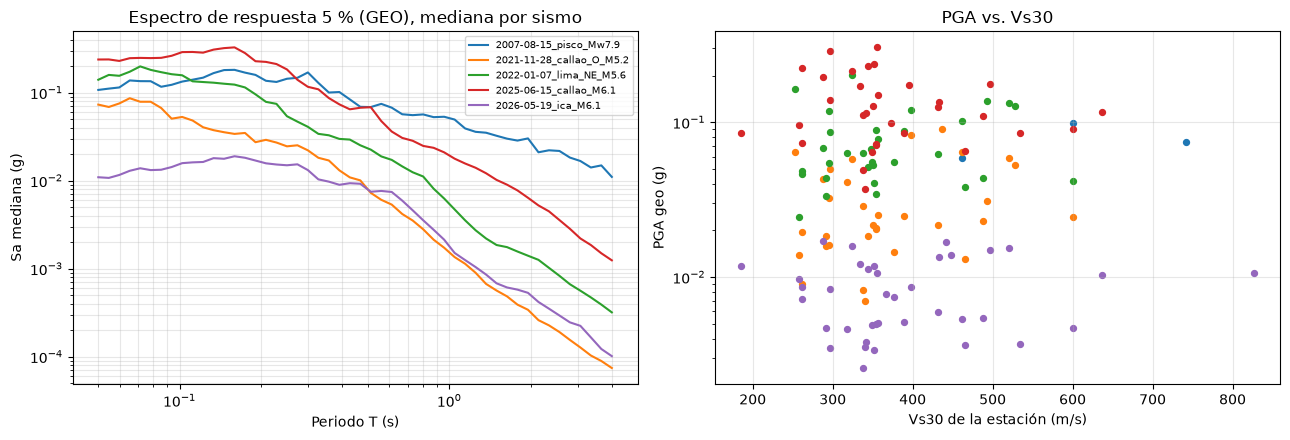

                          estaciones  pga_max_g  tp_mediano_s    vs30_min  \
evento                                                                      
2007-08-15_pisco_Mw7.9             3   0.099518       0.27350  461.099823   
2021-11-28_callao_O_M5.2          32   0.089834       0.07485  253.095337   
2022-01-07_lima_NE_M5.6           32   0.203045       0.07820  253.095337   
2025-06-15_callao_M6.1            32   0.304332       0.13370  185.081207   
2026-05-19_ica_M6.1               38   0.017056       0.14620  185.081207   

                            vs30_max  
evento                                
2007-08-15_pisco_Mw7.9    741.963928  
2021-11-28_callao_O_M5.2  600.000000  
2022-01-07_lima_NE_M5.6   600.000000  
2025-06-15_callao_M6.1    636.878113  
2026-05-19_ica_M6.1       827.195801  


In [34]:
import matplotlib.pyplot as plt

esp = (leer(SILVER, "espectros").where("componente = 'GEO'")
       .groupBy("evento", "T").agg(F.expr("percentile_approx(Sa, 0.5)").alias("Sa_mediana")).toPandas())
reg = leer(SILVER, "ondas_registros").select("evento", "estacion", "vs30", "pga_geo_g", "tp_s").toPandas()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for ev, d in esp.sort_values("T").groupby("evento"):
    ax[0].loglog(d["T"], d["Sa_mediana"], label=ev)
ax[0].set(xlabel="Periodo T (s)", ylabel="Sa mediana (g)", title="Espectro de respuesta 5 % (GEO), mediana por sismo")
ax[0].legend(fontsize=7); ax[0].grid(True, which="both", alpha=.3)
for ev, d in reg.groupby("evento"):
    ax[1].scatter(d["vs30"], d["pga_geo_g"], label=ev, s=18)
ax[1].set(xlabel="Vs30 de la estación (m/s)", ylabel="PGA geo (g)", yscale="log", title="PGA vs. Vs30")
ax[1].grid(True, alpha=.3)
plt.tight_layout(); plt.show()

print(reg.groupby("evento").agg(estaciones=("estacion", "count"), pga_max_g=("pga_geo_g", "max"),
                                tp_mediano_s=("tp_s", "median"), vs30_min=("vs30", "min"), vs30_max=("vs30", "max")))

In [35]:
print(f"Tiempo total: {(time.perf_counter()-INICIO)/60:,.1f} min")
display(inventario(SILVER))

Tiempo total: 2.3 min


,tabla,filas,mb
0,silver.calidad_log,0,0.0
1,silver.espectros,27400,0.2
2,silver.eventos,5,0.0
3,silver.ondas_registros,137,0.3


# Parte 3 · Silver — territorio (distritos, suelo y edificios)

Paso 3 de la metodología.

| Tabla silver | Desde bronze | Qué se hace |
|---|---|---|
| `distritos` | `limites_inei` | Se filtran Lima y Callao (49 distritos); área, centroide y geometría WKT |
| `e030_parametros` | `e030_*` | Perfil de suelo → S, TP, TL para la Zona 4 (Z = 0.45 g) |
| `suelo` | `vs30_pixeles` | Cada píxel de Vs30 → distrito, perfil E.030 (S0–S3), S, TP, TL y celda H3 |
| `microzonificacion_zonas` | `microzonificacion_paginas` | Zonas I–V de cada estudio con su descripción y los perfiles/periodos que cita |
| `edificios` | `open_buildings` + `open_buildings_25d_teselas` | Confianza ≥ 0.75, recorte por distrito (point-in-polygon), H3, Vs30/perfil/TP, **altura → pisos → Tb** |
| `calidad_log` | — | Filas descartadas o imputadas en cada paso |

**Fórmulas** (de la metodología): `pisos = altura / 3` (redondeado, mínimo 1) y `Tb = 0.1 × pisos` (periodo fundamental aproximado de la E.030).

**Operaciones espaciales:** la metodología propone Apache Sedona; en Databricks se usan sus funciones espaciales nativas (`st_contains(st_geomfromwkt(distrito), st_point(lon, lat))`, equivalente a `ST_Within`) con un filtro previo por rectángulo de cada distrito, y las funciones H3 nativas.

In [6]:
INICIO = time.perf_counter()

CONFIANZA_MIN = 0.75
ALTURA_POR_PISO_M = 3.0
H3_RES_EDIFICIO = 9          # ~0.1 km² por hexágono
H3_RES_SUELO = 8             # ~0.7 km², del orden del píxel de Vs30 (~0.86 km²)

## 1. Distritos de Lima y Callao

In [7]:
lim = leer(BRONZE, "limites_inei").where(F.col("NOMBPROV").isin(PROVINCIAS_ESTUDIO)).toPandas()
# El INEI trae La Punta y Santa Anita sin geometría (y los polígonos de Ate y El Agustino cubren Santa Anita):
# se completan con los límites de OpenStreetMap de bronze.limites_complemento_osm
lim["geometria_fuente"] = "INEI"
if spark.catalog.tableExists(f"{CATALOG}.{BRONZE}.limites_complemento_osm"):
    comp = leer(BRONZE, "limites_complemento_osm").select("IDDIST", "geometry_wkt", "fuente").toPandas()
    falta = lim["geometry_wkt"].isna() & lim["IDDIST"].isin(comp["IDDIST"])
    lim.loc[falta, "geometry_wkt"] = lim.loc[falta, "IDDIST"].map(dict(zip(comp["IDDIST"], comp["geometry_wkt"])))
    lim.loc[falta, "geometria_fuente"] = lim.loc[falta, "IDDIST"].map(dict(zip(comp["IDDIST"], comp["fuente"])))
sin_geometria = lim.loc[lim["geometry_wkt"].isna(), "NOMBDIST"].tolist()
lim = lim[lim["geometry_wkt"].notna()].reset_index(drop=True)
gdf = gpd.GeoDataFrame(lim, geometry=gpd.GeoSeries.from_wkt(lim["geometry_wkt"].astype(object)), crs=4326)
invalidas = (~gdf.is_valid).sum()
gdf["geometry"] = gdf.geometry.make_valid()
# Los distritos completados se recortan de los polígonos INEI vecinos que los cubrían (cada punto cae en uno solo)
completados = gdf["geometria_fuente"] != "INEI"
if completados.any():
    area_antes = gdf.to_crs(EPSG_UTM_LIMA).area
    gdf.loc[~completados, "geometry"] = gdf.loc[~completados].geometry.difference(gdf.loc[completados].geometry.union_all())
    recorte = (area_antes - gdf.to_crs(EPSG_UTM_LIMA).area) / 1e6
    print("Completados con OSM:", gdf.loc[completados, "NOMBDIST"].tolist(),
          "| área recortada a vecinos (km²):", {d: round(r, 2) for d, r in zip(gdf["NOMBDIST"], recorte) if r > 0.01},
          "| sin geometría:", sin_geometria)
utm = gdf.to_crs(EPSG_UTM_LIMA)
dist = pd.DataFrame({
    "ubigeo": gdf["IDDIST"], "distrito": gdf["NOMBDIST"], "provincia": gdf["NOMBPROV"], "departamento": gdf["NOMBDEP"],
    "area_km2": (utm.area / 1e6).round(3),
    "centroide_lon": utm.centroid.to_crs(4326).x, "centroide_lat": utm.centroid.to_crs(4326).y,
    "geometry_wkt": gdf.geometry.to_wkt(), "geometria_fuente": gdf["geometria_fuente"],
})
print(f"Distritos: {len(dist)} ({dist.provincia.value_counts().to_dict()}) | geometrías reparadas: {invalidas}")
subir_pandas(dist, SILVER, "distritos")

BBOX = gdf.total_bounds
print("BBOX Lima+Callao:", BBOX.round(3))


def asignar_distrito(df, clave):
    """Agrega ubigeo, distrito y provincia a cada punto (lon, lat). Fuera de los 49 distritos: nulos."""
    return unir_poligonos(df, dist, ["ubigeo", "distrito", "provincia"], clave)

Completados con OSM: ['LA PUNTA', 'SANTA ANITA'] | área recortada a vecinos (km²): {'EL AGUSTINO': 4.95, 'ATE': 5.72} | sin geometría: []
Distritos: 49 ({'LIMA': 43, 'CALLAO': 6}) | geometrías reparadas: 0


  ✓ silver.distritos: 49 filas (1 lote)                    
BBOX Lima+Callao: [-77.194 -12.52  -76.621 -11.576]


## 2. Parámetros E.030 para Lima (Zona 4)

In [8]:
perfiles = leer(BRONZE, "e030_perfiles").drop("_fuente", "_archivo", "_tanda", "_fecha_ingesta")
factor_s = leer(BRONZE, "e030_factor_suelo").where(F.col("zona") == ZONA_E030_LIMA).select("perfil", "S")
z = leer(BRONZE, "e030_zonas").where(F.col("zona") == ZONA_E030_LIMA).first()["Z_g"]
e030 = (perfiles.join(factor_s, "perfil").withColumn("zona", F.lit(ZONA_E030_LIMA)).withColumn("Z_g", F.lit(z))
        .select("perfil", "descripcion", "vs30_min", "vs30_max", "zona", "Z_g", "S", "TP_s", "TL_s").orderBy("perfil"))
escribir_delta(e030, SILVER, "e030_parametros")
e030 = leer(SILVER, "e030_parametros")
E030 = {r["perfil"]: r.asDict() for r in e030.collect()}
e030.orderBy("perfil").show(truncate=False)


def perfil_e030(col_vs30):
    """Tabla 2 de la E.030: S0 > 1500 ; S1 500–1500 ; S2 180–500 ; S3 < 180 (m/s)."""
    return (F.when(col_vs30 > E030["S0"]["vs30_min"], "S0")
             .when(col_vs30 > E030["S1"]["vs30_min"], "S1")
             .when(col_vs30 >= E030["S2"]["vs30_min"], "S2")
             .when(col_vs30.isNotNull(), "S3"))

  ✓ silver.e030_parametros: 4 filas


+------+-------------------------+--------+--------+----+----+----+----+----+
|perfil|descripcion              |vs30_min|vs30_max|zona|Z_g |S   |TP_s|TL_s|
+------+-------------------------+--------+--------+----+----+----+----+----+
|S0    |Roca dura                |1500.0  |NULL    |4   |0.45|0.8 |0.3 |3.0 |
|S1    |Roca o suelos muy rígidos|500.0   |1500.0  |4   |0.45|1.0 |0.4 |2.5 |
|S2    |Suelos intermedios       |180.0   |500.0   |4   |0.45|1.05|0.6 |2.0 |
|S3    |Suelos blandos           |NULL    |180.0   |4   |0.45|1.1 |1.0 |1.6 |
+------+-------------------------+--------+--------+----+----+----+----+----+



## 3. Suelo: Vs30 → perfil E.030
Cada píxel de Vs30 (~0.86 km²) recibe su distrito, perfil, S, TP y TL. Se guarda la grilla completa del rectángulo (`en_area_estudio` distingue los píxeles dentro de Lima/Callao) porque los edificios de la costa pueden caer en un píxel cuyo centro está en el mar.

In [9]:
vs = leer(BRONZE, "vs30_pixeles").select("fila", "col", "lon", "lat", "vs30")
vs_dist = asignar_distrito(vs, ["fila", "col"])

e030_b = F.broadcast(e030.select("perfil", "S", "TP_s", "TL_s", "Z_g"))
suelo = (vs_dist
         .withColumn("perfil", perfil_e030(F.col("vs30")))
         .join(e030_b, "perfil", "left")
         .withColumn("en_area_estudio", F.col("distrito").isNotNull())
         .withColumn("h3_r8", F.expr(f"h3_longlatash3string(lon, lat, {H3_RES_SUELO})"))
         .withColumnRenamed("TP_s", "TP").withColumnRenamed("TL_s", "TL")
         .select("fila", "col", "lon", "lat", "vs30", "perfil", "S", "TP", "TL", "Z_g",
                 "ubigeo", "distrito", "provincia", "en_area_estudio", "h3_r8"))
escribir_delta(suelo, SILVER, "suelo")

s = leer(SILVER, "suelo")
s.where("en_area_estudio").groupBy("perfil").agg(F.count("*").alias("pixeles"), F.round(F.avg("vs30")).alias("vs30_medio")).orderBy("perfil").show()
registrar_calidad(problemas([
    {"fuente": "vs30_usgs", "regla": "pixel_fuera_de_lima_callao", "accion": "fuera_de_alcance", "registro_id": None,
     "detalle": "píxel del rectángulo cuyo centro no cae en ningún distrito (mar u otras provincias); se conserva para el cruce con edificios costeros",
     "n_filas": s.where("NOT en_area_estudio").count()},
    {"fuente": "vs30_usgs", "regla": "vs30_nulo", "accion": "descartado", "registro_id": None,
     "detalle": "píxel sin valor de Vs30", "n_filas": s.where("vs30 IS NULL").count()},
]), "suelo")

  ✓ silver.suelo: 10,125 filas


+------+-------+----------+
|perfil|pixeles|vs30_medio|
+------+-------+----------+
|    S1|   2276|     736.0|
|    S2|   1102|     388.0|
+------+-------+----------+



  calidad_log [suelo] fuera_de_alcance pixel_fuera_de_lima_callao: 6,747
  calidad_log [suelo] descartado  vs30_nulo: 0


## 4. Microzonificación: zonas y periodos de cada estudio
Del texto de los PDF se extraen dos tablas:
- `microzonificacion_zonas`: la descripción de cada zona (I a V) de cada distrito y si menciona rellenos o licuación.
- `microzonificacion_periodos`: cada **rango de periodo predominante** citado (p. ej. "periodos de 0.20 a 0.30 s"), con su página y contexto; sirve para validar el TP de la E.030 y el periodo dominante medido con las ondas.

⚠️ **Limitación:** los polígonos de las zonas y los isoperiodos están como **imágenes** en los PDF; para corregir el suelo píxel a píxel hay que digitalizarlos (QGIS). Mientras tanto, `edificios` marca con `con_microzonificacion` los 4 distritos que tienen estudio.

In [10]:
DISTRITO_PDF = {"cercado_de_lima": "LIMA", "comas": "COMAS", "la_molina": "LA MOLINA", "villa_el_salvador": "VILLA EL SALVADOR"}
ROMANOS = ["I", "II", "III", "IV", "V"]


def normalizar(texto):
    texto = re.sub(r"\s+", " ", texto)
    return re.sub(r"(\d)\s*([.,])\s*(\d)", r"\1.\3", texto)          # "0 .1" o "0,1" -> "0.1"


pag = leer(BRONZE, "microzonificacion_paginas").select("distrito", "pagina", "texto").orderBy("distrito", "pagina").toPandas()
zonas, periodos = [], []
for archivo, d in pag.groupby("distrito"):
    for r in d.itertuples():
        t = normalizar(r.texto)
        for m in re.finditer(r"(\d\.\d+)\s*(?:s|seg\.?)?\s*(?:y|a|–|-|hasta)\s*(\d\.\d+)\s*(?:s|seg)\b", t):
            tmin, tmax = float(m.group(1)), float(m.group(2))
            if 0 < tmin < tmax <= 5:
                periodos.append({"archivo_pdf": archivo, "distrito": DISTRITO_PDF[archivo], "pagina": r.pagina,
                                 "T_min_s": tmin, "T_max_s": tmax, "contexto": t[max(0, m.start() - 200): m.end() + 60]})
    texto = normalizar(" ".join(d.sort_values("pagina")["texto"]))
    marcas = list(re.finditer(r"\bZona\s+(IV|V|I{1,3})\s*[:.\-–]?\s+(?=Esta|Comprende|Corresponde|Se |En |Está|Abarca|Conformad)", texto, re.I))
    for zona in ROMANOS:
        m = next((m for m in marcas if m.group(1).upper() == zona), None)
        if not m:
            continue
        sig = next((n.start() for n in marcas if n.start() > m.start() and n.group(1).upper() != zona), m.end() + 2500)
        desc = texto[m.end(): min(sig, m.end() + 2500)].strip()
        zonas.append({
            "archivo_pdf": archivo, "distrito": DISTRITO_PDF[archivo], "zona": zona,
            "descripcion": desc,
            "perfiles_e030": sorted(set(re.findall(r"\bS[0-4]\b", desc))),
            "periodos_s": sorted({float(x.replace(",", ".")) for x in re.findall(r"(\d[.,]\d{1,2})\s*(?:s\b|seg)", desc)}),
            "menciona_licuacion": bool(re.search(r"licuac", desc, re.I)),
            "menciona_relleno": bool(re.search(r"relleno|desmonte", desc, re.I)),
        })
micro = pd.DataFrame(zonas)
ESQ_ZONAS = ("archivo_pdf string, distrito string, zona string, descripcion string, perfiles_e030 array<string>, "
             "periodos_s array<double>, menciona_licuacion boolean, menciona_relleno boolean")
subir_pandas(micro, SILVER, "microzonificacion_zonas", esquema=ESQ_ZONAS)
per = (pd.DataFrame(periodos, columns=["archivo_pdf", "distrito", "pagina", "T_min_s", "T_max_s", "contexto"])
       .drop_duplicates(["distrito", "pagina", "T_min_s", "T_max_s"]))
subir_pandas(per, SILVER, "microzonificacion_periodos",
             esquema="archivo_pdf string, distrito string, pagina long, T_min_s double, T_max_s double, contexto string")
display(micro[["distrito", "zona", "menciona_relleno", "menciona_licuacion"]].assign(descripcion=micro.descripcion.str[:90]))
per[["distrito", "pagina", "T_min_s", "T_max_s"]]

  ✓ silver.microzonificacion_zonas: 17 filas (1 lote)                    


  ✓ silver.microzonificacion_periodos: 23 filas (1 lote)                    


,distrito,zona,menciona_relleno,menciona_licuacion,descripcion
0,LIMA,I,False,False,Esta zona está conformada por estratos potente...
1,LIMA,III,False,False,Esta z ona está conformada por depósitos de su...
2,LIMA,IV,False,False,Comprende el tramo entre el puente El Ejército...
3,LIMA,V,True,False,Corresponde a acumulaciones de materiales tran...
4,COMAS,I,False,False,Esta zona está conformada por los depósitos cu...
5,COMAS,II,True,False,Esta zona predomina en la región norte del dis...
6,COMAS,III,True,False,Esta zona está localizada en el sector Nor -Oe...
7,COMAS,IV,False,False,Esta zona está asociada a los taludes de fuert...
8,LA MOLINA,I,True,False,Está conformada por las laderas de los cerros ...
9,LA MOLINA,II,False,False,"Abarca la zona relativamente plana, que se ext..."


,distrito,pagina,T_min_s,T_max_s
0,LIMA,16,0.10,0.20
1,LIMA,17,0.20,0.30
2,LIMA,17,0.60,0.70
3,LIMA,19,0.10,0.30
4,LIMA,19,0.60,0.70
5,COMAS,30,0.05,0.22
7,COMAS,30,0.10,0.20
8,COMAS,31,0.10,0.20
9,COMAS,31,0.05,0.15
10,COMAS,31,0.16,0.22


## 5. Edificios
### 5.1 Recorte a Lima y Callao + confianza
Primero un filtro rápido por rectángulo (predicado empujado a Delta), luego el point-in-polygon exacto con el centroide de cada edificio, y por último el umbral de confianza. El resultado del cruce se guarda en una tabla temporal (`silver.tmp_edificios_distrito`) para no repetirlo en los pasos siguientes; se borra al final de la sección.

In [11]:
t0 = time.perf_counter()
ob = leer(BRONZE, "open_buildings")
n_bronze = ob.count()
en_bbox = ob.where(F.col("longitude").between(float(BBOX[0]), float(BBOX[2])) & F.col("latitude").between(float(BBOX[1]), float(BBOX[3])))

base = en_bbox.select(F.col("full_plus_code").alias("id"), F.col("longitude").alias("lon"), F.col("latitude").alias("lat"),
                      F.col("area_in_meters").alias("area_m2"), F.col("confidence").alias("confianza"),
                      F.col("geometry").alias("geometry_wkt"))
escribir_delta(asignar_distrito(base, ["id"]), SILVER, "tmp_edificios_distrito")
con_dist = leer(SILVER, "tmp_edificios_distrito")
n_bbox = con_dist.count()

lima = con_dist.where("distrito IS NOT NULL")
n_lima = lima.count()
baja_conf = lima.where(F.col("confianza") < CONFIANZA_MIN)
edif = lima.where(F.col("confianza") >= CONFIANZA_MIN)
n_dups = edif.groupBy("id").count().where("count > 1").count()
# un id repetido: se conserva la fila de mayor confianza (determinista para que los pasos siguientes coincidan)
edif = (edif.withColumn("_r", F.row_number().over(Window.partitionBy("id").orderBy(F.desc("confianza"), "lon", "lat")))
            .where("_r = 1").drop("_r"))
print(f"bronze: {n_bronze:,} | en rectángulo: {n_bbox:,} | dentro de Lima/Callao: {n_lima:,} | "
      f"confianza ≥ {CONFIANZA_MIN}: {n_lima - baja_conf.count():,} | ids duplicados: {n_dups} | {time.perf_counter()-t0:,.0f} s")

  ✓ silver.tmp_edificios_distrito: 3,198,445 filas


bronze: 7,219,950 | en rectángulo: 3,198,445 | dentro de Lima/Callao: 3,126,310 | confianza ≥ 0.75: 1,921,959 | ids duplicados: 2 | 25 s


### 5.2 H3 y suelo
- `h3_id` (resolución 9) para agregar y mapear; `h3_r8` para cruzar con el suelo (funciones H3 nativas de Databricks).
- Vs30, perfil, S y TP: se une con el píxel de `silver.suelo` que contiene al centroide (clave `fila, col`).

In [12]:
g = leer(BRONZE, "vs30_pixeles").select("grid_origen_lon", "grid_origen_lat", "grid_res").first()
suelo_b = F.broadcast(leer(SILVER, "suelo").select("fila", "col", "vs30", "perfil", "S", "TP", "TL"))
edif = (edif
        .withColumn("h3_id", F.expr(f"h3_longlatash3string(lon, lat, {H3_RES_EDIFICIO})"))
        .withColumn("h3_r8", F.expr(f"h3_toparent(h3_id, {H3_RES_SUELO})"))
        .withColumn("col", F.floor((F.col("lon") - g.grid_origen_lon) / g.grid_res).cast("int"))
        .withColumn("fila", F.floor((g.grid_origen_lat - F.col("lat")) / g.grid_res).cast("int"))
        .join(suelo_b, ["fila", "col"], "left")
        .drop("fila", "col"))

### 5.3 Altura (Open Buildings 2.5D) → pisos → Tb
Los GeoTIFF de altura están en la PC, así que este paso corre en local: se descargan solo `id, lon, lat` de los edificios, se pasan a UTM 18S, cada edificio se asigna a la tesela que contiene su centroide y se lee la altura **tesela por tesela** (4 m/píxel):
1. Altura del píxel del **centroide**.
2. Si ese píxel no tiene edificio (centroide desplazado en techos irregulares), **máximo de la ventana 3×3** (12 × 12 m).
3. Si tampoco hay altura: `pisos = 1` imputado y se registra en `calidad_log`.

El resultado (`id, x_utm, y_utm, tesela, altura_m, altura_metodo`) se sube a `silver.tmp_edificios_altura` y se une en Spark.

In [13]:
from pyproj import Transformer

t0 = time.perf_counter()
teselas = leer(BRONZE, "open_buildings_25d_teselas").select("tesela", "_archivo", "xmin", "ymin", "xmax", "ymax", "res_m", "nodata").toPandas()
print(f"Teselas de altura: {len(teselas)} | resolución: {teselas.res_m.unique()} m")

pos = edif.select("id", "lon", "lat").toPandas()
print(f"Edificios descargados: {len(pos):,} en {time.perf_counter()-t0:,.0f} s")
a_utm = Transformer.from_crs(4326, EPSG_UTM_LIMA, always_xy=True)
pos["x_utm"], pos["y_utm"] = a_utm.transform(pos["lon"].to_numpy(), pos["lat"].to_numpy())

# tesela que contiene el centroide (la primera si hay solape)
x, y = pos["x_utm"].to_numpy(), pos["y_utm"].to_numpy()
tesela = np.full(len(pos), None, dtype=object)
for t in teselas.to_dict("records"):
    dentro = (x >= t["xmin"]) & (x < t["xmax"]) & (y > t["ymin"]) & (y <= t["ymax"]) & (tesela == None)   # noqa: E711
    tesela[dentro] = t["tesela"]
pos["tesela"] = tesela

alt = np.full(len(pos), np.nan)
metodo = np.full(len(pos), "sin_tesela", dtype=object)
info = teselas.set_index("tesela").to_dict("index")
for nombre_t, idx in pos.groupby("tesela").indices.items():
    t = info[nombre_t]
    with rasterio.open(t["_archivo"]) as src:
        h = src.read(1).astype("float32")
    h[(h == t["nodata"]) | ~np.isfinite(h)] = 0.0
    # máximo 3x3 (desplazamientos con borde 0)
    hp = np.pad(h, 1)
    h3x3 = h.copy()
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            np.maximum(h3x3, hp[1 + dy: hp.shape[0] - 1 + dy, 1 + dx: hp.shape[1] - 1 + dx], out=h3x3)
    res = t["res_m"]
    colp = np.clip(((x[idx] - t["xmin"]) // res).astype(int), 0, h.shape[1] - 1)
    filp = np.clip(((t["ymax"] - y[idx]) // res).astype(int), 0, h.shape[0] - 1)
    centro, vecinos = h[filp, colp], h3x3[filp, colp]
    alt[idx] = np.where(centro > 0, centro, np.where(vecinos > 0, vecinos, np.nan))
    metodo[idx] = np.where(centro > 0, "centroide", np.where(vecinos > 0, "max_3x3", "sin_altura"))
pos["altura_m"], pos["altura_metodo"] = alt, metodo
print(pos["altura_metodo"].value_counts().to_dict(), f"| {time.perf_counter()-t0:,.0f} s")

subir_pandas(pos[["id", "x_utm", "y_utm", "tesela", "altura_m", "altura_metodo"]], SILVER, "tmp_edificios_altura",
             esquema="id string, x_utm double, y_utm double, tesela string, altura_m double, altura_metodo string")

Teselas de altura: 44 | resolución: [4.] m


Edificios descargados: 1,921,957 en 13 s


{'centroide': 1718877, 'sin_altura': 152839, 'max_3x3': 50241} | 38 s


  ✓ silver.tmp_edificios_altura: 1,921,957 filas (4 lotes)                    


1921957

In [14]:
t0 = time.perf_counter()
con_altura = edif.join(leer(SILVER, "tmp_edificios_altura"), "id", "left")
pisos = F.greatest(F.lit(1), F.round(F.col("altura_m") / ALTURA_POR_PISO_M)).cast("int")
edificios = (con_altura
    .withColumn("altura_imputada", F.col("altura_m").isNull())
    .withColumn("pisos", F.when(F.col("altura_imputada"), F.lit(1)).otherwise(pisos))
    .withColumn("Tb", F.round(0.1 * F.col("pisos"), 2))
    .withColumn("Tb_TP", F.round(F.col("Tb") / F.col("TP"), 3))
    .withColumn("con_microzonificacion", F.col("distrito").isin(list(DISTRITO_PDF.values())))
    .withColumnRenamed("perfil", "tipo_suelo")
    .select("id", "ubigeo", "distrito", "provincia", "h3_id", "h3_r8", "lon", "lat", "x_utm", "y_utm",
            "area_m2", "confianza", "altura_m", "altura_metodo", "altura_imputada", "pisos", "Tb",
            "vs30", "tipo_suelo", "S", "TP", "TL", "Tb_TP", "con_microzonificacion", "tesela", "geometry_wkt"))
n_edif = escribir_delta(edificios, SILVER, "edificios", particion="provincia")
print(f"Escritura de edificios: {(time.perf_counter()-t0)/60:,.1f} min")

  ✓ silver.edificios: 1,921,957 filas
Escritura de edificios: 0.3 min


### 5.4 Registro de calidad de edificios y limpieza de tablas temporales

In [15]:
e = leer(SILVER, "edificios")
agregados = problemas([
    {"fuente": "open_buildings_v3", "regla": "fuera_del_rectangulo_lima", "accion": "fuera_de_alcance", "registro_id": None,
     "detalle": "edificio de la tesela 911 fuera del rectángulo de Lima/Callao", "n_filas": n_bronze - n_bbox},
    {"fuente": "open_buildings_v3", "regla": "fuera_de_distritos_lima_callao", "accion": "fuera_de_alcance", "registro_id": None,
     "detalle": "centroide dentro del rectángulo pero fuera de los 49 distritos (ST_Within)", "n_filas": n_bbox - n_lima},
    {"fuente": "open_buildings_v3", "regla": "id_duplicado", "accion": "descartado", "registro_id": None,
     "detalle": "full_plus_code repetido; se conserva una fila", "n_filas": n_dups},
])
por_fila = (baja_conf.select(F.lit("open_buildings_v3").alias("fuente"), F.lit(f"confianza<{CONFIANZA_MIN}").alias("regla"),
                             F.lit("descartado").alias("accion"), F.col("id").alias("registro_id"),
                             F.format_string("confianza=%.3f", "confianza").alias("detalle"), F.lit(1).alias("n_filas"))
            .unionByName(e.where("altura_imputada").select(
                F.lit("open_buildings_25d").alias("fuente"), F.lit("sin_altura_2.5D").alias("regla"), F.lit("imputado").alias("accion"),
                F.col("id").alias("registro_id"), F.concat(F.lit("pisos=1; tesela="), F.coalesce("tesela", F.lit("ninguna"))).alias("detalle"),
                F.lit(1).alias("n_filas")))
            .unionByName(e.where("vs30 IS NULL").select(
                F.lit("vs30_usgs").alias("fuente"), F.lit("edificio_sin_vs30").alias("regla"), F.lit("advertencia").alias("accion"),
                F.col("id").alias("registro_id"), F.lit("el píxel de Vs30 no existe en la ventana").alias("detalle"), F.lit(1).alias("n_filas"))))
registrar_calidad(agregados.unionByName(por_fila), "edificios")

for tmp in ["tmp_edificios_distrito", "tmp_edificios_altura"]:
    spark.sql(f"DROP TABLE IF EXISTS {tabla_uc(SILVER, tmp)}")
print("Tablas temporales eliminadas")

  calidad_log [edificios] fuera_de_alcance fuera_del_rectangulo_lima: 4,021,505
  calidad_log [edificios] descartado  confianza<0.75: 1,204,351
  calidad_log [edificios] imputado    sin_altura_2.5D: 152,839
  calidad_log [edificios] fuera_de_alcance fuera_de_distritos_lima_callao: 72,135
  calidad_log [edificios] descartado  id_duplicado: 2


Tablas temporales eliminadas


## 6. Revisión de silver.edificios

In [16]:
resumen = (e.groupBy("provincia").agg(
    F.count("*").alias("edificios"), F.round(F.avg("pisos"), 2).alias("pisos_medio"), F.max("pisos").alias("pisos_max"),
    F.round(100 * F.avg(F.col("altura_imputada").cast("int")), 1).alias("pct_altura_imputada"),
    F.round(F.avg("vs30")).alias("vs30_medio")))
resumen.show()
e.groupBy("tipo_suelo").count().orderBy("tipo_suelo").show()
e.groupBy("altura_metodo").count().show()
dist_rank = (e.groupBy("distrito").agg(F.count("*").alias("edificios"), F.round(F.avg("vs30")).alias("vs30_medio"),
                                       F.round(F.avg("pisos"), 2).alias("pisos_medio"),
                                       F.round(100 * F.avg((F.abs(F.col("Tb_TP") - 1) < 0.2).cast("double")), 1).alias("pct_Tb_cerca_TP"))
             .orderBy("vs30_medio"))
dist_rank.show(10, truncate=False)

+---------+---------+-----------+---------+-------------------+----------+
|provincia|edificios|pisos_medio|pisos_max|pct_altura_imputada|vs30_medio|
+---------+---------+-----------+---------+-------------------+----------+
|     LIMA|  1732211|       1.74|       29|                7.1|     513.0|
|   CALLAO|   189746|       1.76|       21|               15.3|     444.0|
+---------+---------+-----------+---------+-------------------+----------+



+----------+-------+
|tipo_suelo|  count|
+----------+-------+
|        S1| 833742|
|        S2|1088215|
+----------+-------+



+-------------+-------+
|altura_metodo|  count|
+-------------+-------+
|      max_3x3|  50241|
|    centroide|1718877|
|   sin_altura| 152839|
+-------------+-------+



+--------------------------+---------+----------+-----------+---------------+
|distrito                  |edificios|vs30_medio|pisos_medio|pct_Tb_cerca_TP|
+--------------------------+---------+----------+-----------+---------------+
|CALLAO                    |66746    |309.0     |2.4        |5.2            |
|BELLAVISTA                |4415     |315.0     |2.78       |6.3            |
|LOS OLIVOS                |17288    |320.0     |2.72       |5.6            |
|SAN MARTIN DE PORRES      |89021    |326.0     |2.56       |6.8            |
|CARMEN DE LA LEGUA REYNOSO|1502     |336.0     |2.71       |4.3            |
|MAGDALENA VIEJA           |6503     |336.0     |2.87       |8.5            |
|JESUS MARIA               |4857     |339.0     |3.55       |10.5           |
|BREÑA                     |615      |340.0     |3.06       |10.4           |
|LINCE                     |3052     |342.0     |3.26       |9.3            |
|LIMA                      |45678    |347.0     |2.8        |10.

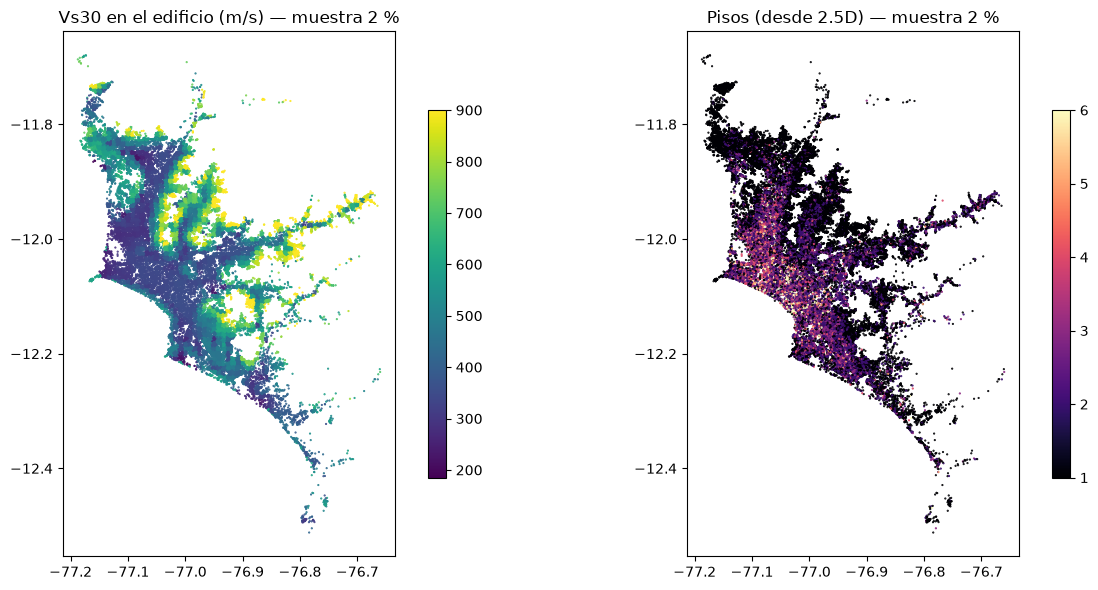

In [17]:
muestra = e.sample(0.02, seed=1).select("lon", "lat", "vs30", "pisos").toPandas()
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
for a, col, titulo, cmap in ((ax[0], "vs30", "Vs30 en el edificio (m/s)", "viridis"), (ax[1], "pisos", "Pisos (desde 2.5D)", "magma")):
    sc = a.scatter(muestra.lon, muestra.lat, c=muestra[col], s=0.3, cmap=cmap,
                   vmax=None if col == "vs30" else np.percentile(muestra.pisos, 99))
    plt.colorbar(sc, ax=a, shrink=.7); a.set_title(titulo + " — muestra 2 %"); a.set_aspect("equal")
plt.tight_layout(); plt.show()

In [18]:
print(f"Tiempo total: {(time.perf_counter()-INICIO)/60:,.1f} min")
display(inventario(SILVER))

Tiempo total: 3.4 min


,tabla,filas,mb
0,silver.calidad_log,1358129,9.3
1,silver.distritos,49,0.0
2,silver.e030_parametros,4,0.0
3,silver.edificios,1921957,238.6
4,silver.espectros,27400,0.2
5,silver.eventos,5,0.0
6,silver.maxar_pares,5,0.0
7,silver.microzonificacion_periodos,23,0.0
8,silver.microzonificacion_zonas,17,0.0
9,silver.ondas_registros,137,0.3


# Parte 4 · Silver — validación (Turquía) y detección de onda P (STEAD)

Prepara en silver las fuentes que usarán los pasos 7 (validación en Turquía) y 8 (tiempo real):

| Tabla silver | Desde bronze | Qué se hace |
|---|---|---|
| `xbd_escenas` | `xbd_indice` + Parquet de raw (PC) | Se decodifican las máscaras PNG y se cuenta el daño por escena (sin daño, leve, severo, destruido); tipo de desastre |
| `maxar_pares` | `maxar_catalogo` + `maxar_imagenes` | Un par antes/después por zona con fechas, resolución, nubes, ángulo y huella en WGS84 |
| `shakemap_turquia` | `shakemap_grid` | PGA y Sa en **g**, PGV en cm/s, Vs30, celda H3 y marca de los puntos dentro de las zonas Maxar |
| `stead_trazas` | `stead_metadata` | Trazas tipadas: sismo/ruido, llegadas P y S en segundos, SNR por componente, magnitud y distancia |

Clases de daño de xBD en `t2_mask` (convención de xView2): 0 fondo · 1 sin daño · 2 daño leve · 3 daño severo · 4 destruido.

In [54]:
INICIO = time.perf_counter()

## 1. xBD — daño por escena
Los Parquet están en la PC: pyarrow lee **solo** las columnas de máscaras por lotes (no se cargan las imágenes RGB), se decodifica cada PNG y se cuentan píxeles por clase. El conteo se sube y se une en Spark con `bronze.xbd_indice`.

In [55]:
from PIL import Image

CLASES = {1: "px_sin_dano", 2: "px_dano_leve", 3: "px_dano_severo", 4: "px_destruido"}
ESQ_MASCARAS = T.StructType([
    T.StructField("image_name", T.StringType()), T.StructField("_archivo", T.StringType()),
    T.StructField("px_edificio_pre", T.LongType()), T.StructField("px_edificio_post", T.LongType()),
    *[T.StructField(c, T.LongType()) for c in CLASES.values()],
    T.StructField("ancho", T.LongType()), T.StructField("alto", T.LongType()),
    T.StructField("error", T.StringType()),
])

t0 = time.perf_counter()
filas = []
for archivo in sorted((RAW / "xbd" / "data").glob("*.parquet")):
    for lote in pq.ParquetFile(archivo).iter_batches(batch_size=256, columns=["image_name", "t1_mask", "t2_mask"]):
        nombres = lote.column("image_name").to_pylist()
        pre_b = lote.column("t1_mask").field("bytes").to_pylist()
        post_b = lote.column("t2_mask").field("bytes").to_pylist()
        for nombre_img, b1, b2 in zip(nombres, pre_b, post_b):
            fila = {"image_name": nombre_img, "_archivo": archivo.as_posix(), "error": None}
            try:
                pre = np.asarray(Image.open(io.BytesIO(b1)))
                post = np.asarray(Image.open(io.BytesIO(b2)))
                cuentas = np.bincount(post.ravel(), minlength=5)
                fila.update(px_edificio_pre=int((pre > 0).sum()), px_edificio_post=int((post > 0).sum()),
                            alto=post.shape[0], ancho=post.shape[1],
                            **{n: int(cuentas[k]) for k, n in CLASES.items()})
            except Exception as ex:
                fila["error"] = f"{type(ex).__name__}: {ex}"[:200]
            filas.append(fila)
    print(f"  {archivo.name}: {len(filas):,} escenas acumuladas")
masc = pd.DataFrame(filas).reindex(columns=[f.name for f in ESQ_MASCARAS.fields])
for c in [f.name for f in ESQ_MASCARAS.fields if isinstance(f.dataType, T.LongType)]:
    masc[c] = masc[c].astype("Int64")
mascaras = a_spark(masc, ESQ_MASCARAS)

indice = leer(BRONZE, "xbd_indice").select("image_name", "_archivo", "split")
TIPO_DESASTRE = {"earthquake": "sismo", "tsunami": "tsunami", "flooding": "inundacion", "fire": "incendio",
                 "hurricane": "huracan", "volcano": "volcan", "tornado": "tornado", "wildfire": "incendio"}
tipo = F.lit(None).cast("string")
for clave, valor in TIPO_DESASTRE.items():
    tipo = F.when(F.col("desastre").contains(clave), valor).otherwise(tipo)

px_post = F.col("px_edificio_post")
xbd = (mascaras.join(indice, ["image_name", "_archivo"], "left")
       .withColumn("escena", F.regexp_extract("image_name", r"/([^/]+)$", 1))
       .withColumn("desastre", F.regexp_extract("escena", r"^(.+)_\d+$", 1))
       .withColumn("tipo_desastre", tipo)
       .withColumn("relevante_sismo", F.col("tipo_desastre").isin("sismo", "tsunami"))
       .withColumn("pct_danado", F.when(px_post > 0, 100 * (F.col("px_dano_leve") + F.col("px_dano_severo") + F.col("px_destruido")) / px_post))
       .withColumn("pct_severo_o_destruido", F.when(px_post > 0, 100 * (F.col("px_dano_severo") + F.col("px_destruido")) / px_post))
       .withColumn("clase_dominante", F.when(px_post == 0, "sin_edificios").otherwise(
           F.element_at(F.array(*[F.lit(n.replace("px_", "")) for n in CLASES.values()]),
                        F.array_position(F.array(*[F.col(n) for n in CLASES.values()]),
                                         F.greatest(*[F.col(n) for n in CLASES.values()])).cast("int"))))
       .select("image_name", "escena", "split", "desastre", "tipo_desastre", "relevante_sismo", "ancho", "alto",
               "px_edificio_pre", "px_edificio_post", *CLASES.values(), "pct_danado", "pct_severo_o_destruido",
               "clase_dominante", "error", "_archivo"))
escribir_delta(xbd, SILVER, "xbd_escenas", particion="split")
print(f"xBD: {(time.perf_counter()-t0)/60:,.1f} min")

x = leer(SILVER, "xbd_escenas")
registrar_calidad(x.where("error IS NOT NULL OR px_edificio_post = 0").select(
    F.lit("xbd").alias("fuente"),
    F.when(F.col("error").isNotNull(), "mascara_ilegible").otherwise("escena_sin_edificios").alias("regla"),
    F.when(F.col("error").isNotNull(), "descartado").otherwise("advertencia").alias("accion"),
    F.col("image_name").alias("registro_id"), F.coalesce("error", F.lit("t2_mask sin edificios: útil solo como negativo")).alias("detalle"),
    F.lit(1).alias("n_filas")), "xbd_escenas")
x.groupBy("tipo_desastre").agg(F.count("*").alias("escenas"), F.sum("px_destruido").alias("px_destruido"),
                               F.round(F.avg("pct_danado"), 1).alias("pct_danado_medio")).orderBy(F.desc("escenas")).show()

  hold-00000-of-00006.parquet: 156 escenas acumuladas
  hold-00001-of-00006.parquet: 312 escenas acumuladas
  hold-00002-of-00006.parquet: 468 escenas acumuladas
  hold-00003-of-00006.parquet: 623 escenas acumuladas
  hold-00004-of-00006.parquet: 778 escenas acumuladas
  hold-00005-of-00006.parquet: 933 escenas acumuladas
  test-00000-of-00006.parquet: 1,089 escenas acumuladas
  test-00001-of-00006.parquet: 1,245 escenas acumuladas
  test-00002-of-00006.parquet: 1,401 escenas acumuladas
  test-00003-of-00006.parquet: 1,556 escenas acumuladas
  test-00004-of-00006.parquet: 1,711 escenas acumuladas
  test-00005-of-00006.parquet: 1,866 escenas acumuladas
  tier3-00000-of-00021.parquet: 2,027 escenas acumuladas
  tier3-00001-of-00021.parquet: 2,188 escenas acumuladas
  tier3-00002-of-00021.parquet: 2,349 escenas acumuladas
  tier3-00003-of-00021.parquet: 2,510 escenas acumuladas
  tier3-00004-of-00021.parquet: 2,671 escenas acumuladas
  tier3-00005-of-00021.parquet: 2,832 escenas acumulada

## 2. Maxar — pares antes/después

In [56]:
from shapely.geometry import box
from shapely.ops import transform as transformar

img = leer(BRONZE, "maxar_imagenes").toPandas()
# bronze guarda el catálogo como texto: la fecha se toma literal del texto UTC ("2023-02-08 08:12:..+00:00")
cat = (leer(BRONZE, "maxar_catalogo")
       .select("quadkey", "catalog_id", F.substring("datetime", 1, 10).alias("fecha"), "platform",
               F.col("gsd").cast("double").alias("gsd"), F.col("view_off_nadir").cast("double").alias("off_nadir"),
               F.col("tile_clouds_percent").cast("double").alias("nubes_pct"))
       .dropDuplicates(["quadkey", "catalog_id", "fecha"]).toPandas())
img = img.merge(cat, on=["quadkey", "catalog_id", "fecha"], how="left")


def huella_wgs84(r):
    a_wgs = Transformer.from_crs(int(r.epsg), 4326, always_xy=True).transform
    return transformar(a_wgs, box(r.xmin, r.ymin, r.xmax, r.ymax))


img["huella"] = img.apply(huella_wgs84, axis=1)
pares = []
for qk, d in img.groupby("quadkey"):
    antes, despues = d[d.momento == "antes"].iloc[0], d[d.momento == "despues"].iloc[0]
    comun = antes.huella.intersection(despues.huella)
    pares.append({
        "quadkey": qk,
        "fecha_antes": antes.fecha, "fecha_despues": despues.fecha,
        "dias_entre": (pd.Timestamp(despues.fecha) - pd.Timestamp(antes.fecha)).days,
        "catalog_antes": antes.catalog_id, "catalog_despues": despues.catalog_id,
        "satelite_antes": antes.platform, "satelite_despues": despues.platform,
        "gsd_antes_m": antes.gsd, "gsd_despues_m": despues.gsd,
        "off_nadir_antes": antes.off_nadir, "off_nadir_despues": despues.off_nadir,
        "nubes_antes_pct": antes.nubes_pct, "nubes_despues_pct": despues.nubes_pct,
        "res_m": float(antes.res_m), "epsg": int(antes.epsg),
        "solape_pct": round(100 * comun.area / antes.huella.area, 1),
        "centro_lon": comun.centroid.x, "centro_lat": comun.centroid.y,
        "huella_wkt": comun.wkt,
        "archivo_antes": antes["_archivo"], "archivo_despues": despues["_archivo"],
    })
maxar = pd.DataFrame(pares)
subir_pandas(maxar, SILVER, "maxar_pares")
maxar[["quadkey", "fecha_antes", "fecha_despues", "dias_entre", "gsd_antes_m", "gsd_despues_m", "solape_pct", "centro_lon", "centro_lat"]]

C:\Users\andre\AppData\Local\Temp\ipykernel_25184\3640942567.py:16: DeprecationWarning: The 'shapely.ops.transform()' function is deprecated. Use 'shapely.transform()' or 'shapely.transform_coordseq()' instead. See https://shapely.readthedocs.io/en/latest/manual.html#shapely.ops.transform for more details.
  return transformar(a_wgs, box(r.xmin, r.ymin, r.xmax, r.ymax))


  ✓ silver.maxar_pares: 5 filas (1 lote)                    


,quadkey,fecha_antes,fecha_despues,dias_entre,gsd_antes_m,gsd_despues_m,solape_pct,centro_lon,centro_lat
0,031133012123,2022-12-27,2023-02-07,42,0.49,0.31,100.0,36.610510,37.044686
1,031133012301,2022-12-27,2023-02-07,42,0.49,0.48,100.0,36.611921,36.999653
2,031133102032,2023-01-02,2023-02-08,37,0.53,0.82,100.0,37.341072,37.057156
3,031133102033,2023-01-02,2023-02-08,37,0.52,0.82,100.0,37.397287,37.057929
4,031133113102,2023-01-02,2023-02-09,38,0.55,0.48,100.0,38.802908,37.158736


## 3. ShakeMap Turquía
Conversión de unidades: PGA y PSA vienen en **%g** → se dividen entre 100 para tener **g**. `SVEL` es el Vs30 (m/s) que usó el ShakeMap. Cada punto se marca con la zona Maxar que lo contiene (point-in-polygon) y su celda H3.

In [57]:
sm = leer(BRONZE, "shakemap_grid")
sm = sm.select(F.col("LON").alias("lon"), F.col("LAT").alias("lat"), F.col("MMI").alias("mmi"),
               (F.col("PGA") / 100).alias("pga_g"), F.col("PGV").alias("pgv_cms"),
               (F.col("PSA03") / 100).alias("sa03_g"), (F.col("PSA06") / 100).alias("sa06_g"),
               (F.col("PSA10") / 100).alias("sa10_g"), (F.col("PSA30") / 100).alias("sa30_g"),
               F.col("SVEL").alias("vs30"), "event_id", "magnitud", "shakemap_version")
huellas = maxar[["quadkey", "huella_wkt"]].rename(columns={"quadkey": "quadkey_maxar", "huella_wkt": "geometry_wkt"})
shakemap = (unir_poligonos(sm, huellas, ["quadkey_maxar"], ["lon", "lat"])
            .withColumn("h3_r8", F.expr("h3_longlatash3string(lon, lat, 8)"))
            .withColumn("en_zona_maxar", F.col("quadkey_maxar").isNotNull()))
escribir_delta(shakemap, SILVER, "shakemap_turquia")

st = leer(SILVER, "shakemap_turquia")
st.where("en_zona_maxar").groupBy("quadkey_maxar").agg(
    F.count("*").alias("puntos"), F.round(F.avg("pga_g"), 3).alias("pga_g"), F.round(F.avg("sa03_g"), 3).alias("sa03_g"),
    F.round(F.avg("sa10_g"), 3).alias("sa10_g"), F.round(F.avg("mmi"), 1).alias("mmi"), F.round(F.avg("vs30")).alias("vs30")).show()
registrar_calidad(st.where("pga_g IS NULL OR vs30 IS NULL OR pga_g < 0").select(
    F.lit("shakemap_usgs").alias("fuente"), F.lit("valor_nulo_o_negativo").alias("regla"), F.lit("advertencia").alias("accion"),
    F.format_string("%.4f,%.4f", "lon", "lat").alias("registro_id"), F.lit("PGA o Vs30 inválido").alias("detalle"),
    F.lit(1).alias("n_filas")), "shakemap_turquia")

  ✓ silver.shakemap_turquia: 467,929 filas
+-------------+------+-----+------+------+---+-----+
|quadkey_maxar|puntos|pga_g|sa03_g|sa10_g|mmi| vs30|
+-------------+------+-----+------+------+---+-----+
| 031133113102|    35|0.099|  0.19| 0.137|6.0|397.0|
| 031133102032|    39| 0.24|  0.54| 0.232|7.6|364.0|
| 031133102033|    35|0.223| 0.465| 0.217|7.5|377.0|
| 031133012123|    42|0.801| 1.607| 1.033|8.9|579.0|
| 031133012301|    38|0.684| 1.611| 0.956|8.9|565.0|
+-------------+------+-----+------+------+---+-----+



## 4. STEAD — trazas para el detector de onda P
Muestreo de STEAD: 100 Hz, 60 s por traza (6000 muestras, 3 componentes E-N-Z). Las llegadas vienen en número de muestra → se pasan a segundos. `snr_db` viene como texto `"[e n z]"`.

In [58]:
FS_STEAD = 100.0
sd = leer(BRONZE, "stead_metadata")
snr = F.split(F.regexp_replace("snr_db", r"[\[\]]", ""), r"\s+")
stead = (sd
    .withColumn("snr_arr", F.filter(snr, lambda s: s != ""))
    .select("trace_name", "trace_category", (F.col("trace_category") == "earthquake_local").alias("es_sismo"),
            "network_code", "receiver_code", "receiver_type", "receiver_latitude", "receiver_longitude",
            "p_arrival_sample", "p_status", "p_weight", "s_arrival_sample", "s_status", "s_weight",
            (F.col("p_arrival_sample") / FS_STEAD).alias("p_segundos"), (F.col("s_arrival_sample") / FS_STEAD).alias("s_segundos"),
            ((F.col("s_arrival_sample") - F.col("p_arrival_sample")) / FS_STEAD).alias("s_menos_p_s"),
            "source_magnitude", "source_magnitude_type", "source_distance_km", "source_depth_km",
            "source_latitude", "source_longitude", "back_azimuth_deg",
            F.col("snr_arr")[0].cast("double").alias("snr_e_db"), F.col("snr_arr")[1].cast("double").alias("snr_n_db"),
            F.col("snr_arr")[2].cast("double").alias("snr_z_db"),
            "coda_end_sample", "trace_start_time", "_archivo_hdf5"))
fallas = stead.where(F.col("es_sismo") & (F.col("p_arrival_sample").isNull() | F.col("source_magnitude").isNull()))
stead_ok = stead.join(fallas.select("trace_name"), "trace_name", "left_anti")
escribir_delta(stead_ok, SILVER, "stead_trazas")
registrar_calidad(fallas.select(
    F.lit("stead").alias("fuente"), F.lit("sismo_sin_llegada_P_o_magnitud").alias("regla"), F.lit("descartado").alias("accion"),
    F.col("trace_name").alias("registro_id"), F.lit("no sirve para entrenar el detector de onda P").alias("detalle"),
    F.lit(1).alias("n_filas")), "stead_trazas")

s = leer(SILVER, "stead_trazas")
s.groupBy("trace_category").agg(F.count("*").alias("trazas"), F.round(F.avg("source_magnitude"), 2).alias("mag_media"),
                                F.round(F.expr("percentile_approx(p_segundos, 0.5)"), 1).alias("p_mediana_s"),
                                F.round(F.avg("snr_z_db"), 1).alias("snr_z_medio")).show()

  ✓ silver.stead_trazas: 200,000 filas
+----------------+------+---------+-----------+-----------+
|  trace_category|trazas|mag_media|p_mediana_s|snr_z_medio|
+----------------+------+---------+-----------+-----------+
|earthquake_local|200000|     1.33|        7.0|        NaN|
+----------------+------+---------+-----------+-----------+



## Resumen

In [59]:
print(f"Tiempo total: {(time.perf_counter()-INICIO)/60:,.1f} min")
display(inventario(SILVER))
display(leer(SILVER, "calidad_log").groupBy("tabla", "accion").agg(F.sum("n_filas").alias("filas")).orderBy("tabla", "accion").toPandas())

Tiempo total: 3.2 min


,tabla,filas,mb
0,silver.calidad_log,1356762,9.3
1,silver.distritos,49,0.0
2,silver.e030_parametros,4,0.0
3,silver.edificios,1921174,238.5
4,silver.espectros,27400,0.2
5,silver.eventos,5,0.0
6,silver.maxar_pares,5,0.0
7,silver.microzonificacion_periodos,23,0.0
8,silver.microzonificacion_zonas,17,0.0
9,silver.ondas_registros,137,0.3


,tabla,accion,filas
0,edificios,descartado,1203722
1,edificios,fuera_de_alcance,4095054
2,edificios,imputado,152103
3,suelo,descartado,0
4,suelo,fuera_de_alcance,6747
5,xbd_escenas,advertencia,934


# Parte 5 · Gold — amplificación, demanda y daño (pasos 4, 5 y 6)

| Paso | Tabla gold | Qué se hace | Modelo |
|---|---|---|---|
| 4 | `amplificacion_lima` | Cociente espectral contra estaciones en suelo firme → `F(T, Vs30)` en una grilla de Vs30 × 50 periodos (con intervalo p10–p90) | **Random Forest** de regresión sobre `ln F`, validación *leave-one-event-out* |
| 5 | `escenarios`, `sa_roca_h3` | Espectro en **roca** de cada estación (`Sa / F`) → **kriging ordinario** a las celdas H3 r8 con edificios; 5 sismos registrados + 5 escalados al sismo de diseño (Z = 0.45 g) | Kriging (variograma exponencial) |
| 5 | `demanda` | Por edificio y escenario: `Sa(Tb) = Sa_roca(Tb) × F(Tb, Vs30)` interpolando en log(T); índice de resonancia `Tb/TP`; PGV | — |
| 6 | `fragilidad_parametros`, `dano_edificios` | Tipología supuesta por distrito y pisos → **curvas de fragilidad lognormales** → P(leve, moderado, severo, colapso) y daño esperado | Fragilidad lognormal |
| 6 | `perfiles_riesgo` | Perfiles de riesgo sobre (ln Sa(Tb), Tb/TP, Vs30, pisos) estandarizados; k elegido por silueta (3 a 8) | **K-means** |
| 6 | `ranking_distritos`, `riesgo_h3` | Agregación por distrito y por hexágono H3 r8 para el mapa | — |

Los modelos se entrenan en la PC (las tablas de entrenamiento son pequeñas: ~6 800 filas de espectros y una muestra de 200 000 filas para K-means) y se aplican a los 19.2 M registros de demanda/daño **en Spark** con expresiones nativas.

In [19]:
INICIO = time.perf_counter()
import matplotlib.pyplot as plt
from pyproj import Transformer
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut

# Insumos de silver (así la Parte 5 se puede ejecutar sola, después de la Parte 0)
PERIODOS = np.array([r["T"] for r in leer(SILVER, "espectros").select("indice_periodo", "T").distinct().orderBy("indice_periodo").collect()])
E030 = {r["perfil"]: r.asDict() for r in leer(SILVER, "e030_parametros").collect()}
Z_DISENO = float(E030["S1"]["Z_g"])                    # 0.45 g (Zona 4)
dist = leer(SILVER, "distritos").toPandas()
DISTRITO_PDF = {"cercado_de_lima": "LIMA", "comas": "COMAS", "la_molina": "LA MOLINA", "villa_el_salvador": "VILLA EL SALVADOR"}
a_utm = Transformer.from_crs(4326, EPSG_UTM_LIMA, always_xy=True)

# ---------------- Registro de modelos ----------------
METRICAS = []          # (modelo, metrica, valor) -> gold.metricas_modelos
try:
    import mlflow
    import mlflow.sklearn
    mlflow.set_tracking_uri(f"databricks://{PROFILE}")
    mlflow.set_experiment(f"/Users/{ws.current_user.me().user_name}/Grupo06_ProyectoFinal")
    USAR_MLFLOW = True
except Exception as e:
    USAR_MLFLOW = False
    print("MLflow no disponible (las métricas igual se guardan en gold.metricas_modelos):", str(e).splitlines()[0][:120])


def registrar_modelo(nombre_modelo, params, metricas, modelo=None):
    """Guarda las métricas para gold.metricas_modelos y, si hay MLflow, registra el run con el modelo."""
    for k, v in metricas.items():
        METRICAS.append({"modelo": nombre_modelo, "metrica": k, "valor": float(v)})
    print(f"  {nombre_modelo}: " + " | ".join(f"{k} = {v:,.4f}" for k, v in metricas.items()))
    if USAR_MLFLOW:
        try:
            with mlflow.start_run(run_name=nombre_modelo):
                mlflow.log_params({k: str(v) for k, v in params.items()})
                mlflow.log_metrics({k: float(v) for k, v in metricas.items()})
                if modelo is not None:
                    mlflow.sklearn.log_model(modelo, "modelo")
        except Exception as e:
            print("    (MLflow: no se pudo registrar el run)", str(e).splitlines()[0][:120])
print("Periodos:", len(PERIODOS), "| Z diseño:", Z_DISENO, "g | MLflow:", USAR_MLFLOW)

MLflow no disponible (las métricas igual se guardan en gold.metricas_modelos): No module named 'mlflow'
Periodos: 50 | Z diseño: 0.45 g | MLflow: False


## 5.1 Paso 4 — Efecto del suelo medido con las ondas: `amplificacion_lima`
1. Por evento, **referencia** = media (en log) de las estaciones con Vs30 ≥ 500 m/s (suelo firme); si un evento no tiene ninguna, la(s) de mayor Vs30.
2. Corrección por distancia (atenuación geométrica 1/R): se compara `Sa·R` en vez de `Sa`.
3. Cociente espectral: `ln F_obs(T) = ln(Sa_est·R_est) − media ln(Sa_ref·R_ref)` (componente GEO).
4. **Random Forest** de regresión `ln F = f(ln T, ln Vs30)` con **todas** las estaciones, incluidas las de referencia: su `ln F ≈ 0` ancla F ≈ 1 en suelo firme (sin ellas el bosque solo veía Vs30 < 500 y extrapolaba a todo S1, lo que invertía S2/S1); validación dejando un evento fuera (RMSE de ln F frente a un modelo base que predice la media).
5. Con el bosque se arma la tabla de consulta `F(T, Vs30)` para Vs30 = 150…1000 m/s cada 10 m/s; el intervalo p10–p90 sale de la dispersión entre árboles y `extrapolado` marca los Vs30 fuera del rango de entrenamiento.

In [20]:
VS30_REF_MIN = 500.0
VS30_GRID = np.arange(150.0, 1001.0, 10.0)

espd = (leer(SILVER, "espectros").where("componente = 'GEO'")
        .select("evento", "archivo_estacion", "estacion", "lat", "lon", "vs30", "dist_hipo_km", "indice_periodo", "T", "Sa")
        .toPandas())
espd = espd[espd.vs30.notna() & (espd.Sa > 0) & espd.dist_hipo_km.notna()].copy()
espd["ln_sa_r"] = np.log(espd.Sa * espd.dist_hipo_km)             # Sa normalizada por atenuación geométrica 1/R
vs30_max_evento = espd.groupby("evento").vs30.transform("max")
espd["es_referencia"] = espd.vs30 >= np.minimum(VS30_REF_MIN, vs30_max_evento)
ref = (espd[espd.es_referencia].groupby(["evento", "indice_periodo"])
       .agg(ln_ref=("ln_sa_r", "mean"), n_ref=("archivo_estacion", "nunique")).reset_index())
espd = espd.merge(ref, on=["evento", "indice_periodo"])
espd["ln_F"] = espd.ln_sa_r - espd.ln_ref
print(espd.groupby("evento").agg(estaciones=("archivo_estacion", "nunique"), referencias=("n_ref", "first")))


def rasgos_amp(T, vs30):
    return np.column_stack([np.log(np.asarray(T, float)), np.log(np.asarray(vs30, float))])


# Se entrena con TODAS las estaciones: las de referencia (Vs30 >= 500) tienen ln F ~ 0 por construcción y anclan
# F ~ 1 en suelo firme. Sin ellas el bosque solo veía Vs30 < 500 y extrapolaba en plano a todo S1 (F ~ 1.95, S2/S1 < 1).
entreno = espd
VS30_ENTRENO = (float(entreno.vs30.min()), float(entreno.vs30.max()))
print(f"Vs30 de entrenamiento: {VS30_ENTRENO[0]:.0f}-{VS30_ENTRENO[1]:.0f} m/s | filas: {len(entreno):,} "
      f"(de estaciones de referencia: {int(entreno.es_referencia.sum()):,})")
X, y, grupos = rasgos_amp(entreno["T"], entreno.vs30), entreno.ln_F.to_numpy(), entreno.evento.to_numpy()
PARAMS_RF = dict(n_estimators=300, min_samples_leaf=20, random_state=1, n_jobs=-1)

cv = []
for i_tr, i_te in LeaveOneGroupOut().split(X, y, grupos):
    m = RandomForestRegressor(**PARAMS_RF).fit(X[i_tr], y[i_tr])
    cv.append({"evento_fuera": grupos[i_te][0], "filas": len(i_te),
               "rmse_lnF": float(np.sqrt(np.mean((m.predict(X[i_te]) - y[i_te]) ** 2))),
               "rmse_base": float(np.sqrt(np.mean((y[i_tr].mean() - y[i_te]) ** 2)))})
cv = pd.DataFrame(cv)
display(cv)

rf_amp = RandomForestRegressor(**PARAMS_RF).fit(X, y)
registrar_modelo("amplificacion_random_forest", PARAMS_RF | {"rasgos": "ln_T, ln_vs30", "vs30_ref_min": VS30_REF_MIN},
                 {"rmse_lnF_loeo": cv.rmse_lnF.mean(), "rmse_base_loeo": cv.rmse_base.mean(), "filas_entreno": len(y)}, rf_amp)


def amplificacion(T, vs30):
    """F(T, Vs30) predicha por el bosque."""
    return np.exp(rf_amp.predict(rasgos_amp(T, vs30)))


# Tabla de consulta F(T, Vs30)
gT, gV = np.meshgrid(PERIODOS, VS30_GRID)                          # filas: Vs30, columnas: T
Xg = rasgos_amp(gT.ravel(), gV.ravel())
por_arbol = np.stack([arbol.predict(Xg) for arbol in rf_amp.estimators_])
amp = pd.DataFrame({"vs30": gV.ravel(), "indice_periodo": np.tile(np.arange(len(PERIODOS)), len(VS30_GRID)),
                    "T": gT.ravel(), "ln_F": rf_amp.predict(Xg)})
amp["F"] = np.exp(amp.ln_F)
amp["F_p10"] = np.exp(np.percentile(por_arbol, 10, axis=0))
amp["F_p90"] = np.exp(np.percentile(por_arbol, 90, axis=0))
amp["perfil_e030"] = np.select([amp.vs30 > 1500, amp.vs30 > 500, amp.vs30 >= 180], ["S0", "S1", "S2"], "S3")
amp["extrapolado"] = (amp.vs30 < VS30_ENTRENO[0]) | (amp.vs30 > VS30_ENTRENO[1])   # Vs30 fuera de lo visto al entrenar
subir_pandas(amp, GOLD, "amplificacion_lima")
F_GRID = amp.F.to_numpy().reshape(len(VS30_GRID), len(PERIODOS))

                          estaciones  referencias
evento                                           
2007-08-15_pisco_Mw7.9             3            2
2021-11-28_callao_O_M5.2          32            3
2022-01-07_lima_NE_M5.6           32            3
2025-06-15_callao_M6.1            32            3
2026-05-19_ica_M6.1               38            5
Vs30 de entrenamiento: 185-827 m/s | filas: 6,850 (de estaciones de referencia: 800)


,evento_fuera,filas,rmse_lnF,rmse_base
0,2007-08-15_pisco_Mw7.9,150,0.299203,0.504935
1,2021-11-28_callao_O_M5.2,1600,0.479813,0.667460
2,2022-01-07_lima_NE_M5.6,1600,0.498588,0.640775
3,2025-06-15_callao_M6.1,1600,0.567289,0.674401
4,2026-05-19_ica_M6.1,1900,0.461891,0.654876


  amplificacion_random_forest: rmse_lnF_loeo = 0.4614 | rmse_base_loeo = 0.6285 | filas_entreno = 6,850.0000


  ✓ gold.amplificacion_lima: 4,300 filas (1 lote)                    


### Validación de la amplificación
- Contra la **E.030**: el cociente S2/S1 de la norma (1.05/1.00) frente al cociente de F medio en la meseta (T ≤ TP de S1).
- Contra la **microzonificación**: periodo predominante Tp de las estaciones ubicadas en los 4 distritos con estudio frente a los rangos de periodo citados en los PDF.

F medio en la meseta (T ≤ TP de S1): {'S1': 1.127, 'S2': 1.314, 'S3': 1.785}
S2/S1 medido = 1.167   |   S2/S1 E.030 = 1.050


,distrito,registros,tp_mediano_s,vs30_medio,T_min_microzon_s,T_max_microzon_s
0,COMAS,4,0.1557,356.316620,0.05,0.22
1,LA MOLINA,9,0.0715,399.752977,0.10,0.40
2,LIMA,3,0.1599,340.568726,0.10,0.70
3,VILLA EL SALVADOR,4,0.1039,464.826492,0.20,1.20


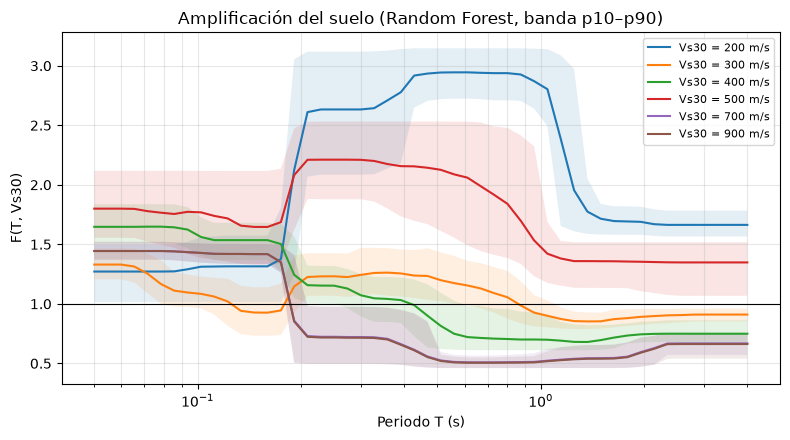

In [21]:
meseta = amp[amp["T"] <= E030["S1"]["TP_s"]].groupby("perfil_e030").F.mean()
print("F medio en la meseta (T ≤ TP de S1):", meseta.round(3).to_dict())
if {"S1", "S2"} <= set(meseta.index):
    print(f"S2/S1 medido = {meseta['S2'] / meseta['S1']:.3f}   |   S2/S1 E.030 = {E030['S2']['S'] / E030['S1']['S']:.3f}")

est = leer(SILVER, "ondas_registros").select("evento", "archivo_estacion", "estacion", "lon", "lat", "tp_s", "vs30")
est_d = unir_poligonos(est, dist, ["distrito"], ["evento", "archivo_estacion"]).where(F.col("distrito").isin(list(DISTRITO_PDF.values()))).toPandas()
mz = (leer(SILVER, "microzonificacion_periodos").groupBy("distrito")
      .agg(F.min("T_min_s").alias("T_min_microzon_s"), F.max("T_max_s").alias("T_max_microzon_s")).toPandas())
if len(est_d):
    display(est_d.groupby("distrito").agg(registros=("tp_s", "count"), tp_mediano_s=("tp_s", "median"), vs30_medio=("vs30", "mean"))
            .reset_index().merge(mz, on="distrito", how="left"))
else:
    print("Ninguna estación CISMID cae en los 4 distritos con microzonificación.")

fig, ax = plt.subplots(figsize=(8, 4.5))
for v in [200, 300, 400, 500, 700, 900]:
    i = int(np.argmin(np.abs(VS30_GRID - v)))
    d = amp[amp.vs30 == VS30_GRID[i]]
    ax.semilogx(d["T"], d["F"], label=f"Vs30 = {VS30_GRID[i]:.0f} m/s")
    ax.fill_between(d["T"], d["F_p10"], d["F_p90"], alpha=.12)
ax.axhline(1, color="k", lw=.8)
ax.set(xlabel="Periodo T (s)", ylabel="F(T, Vs30)", title="Amplificación del suelo (Random Forest, banda p10–p90)")
ax.legend(fontsize=8); ax.grid(True, which="both", alpha=.3)
plt.tight_layout(); plt.show()

## 5.2 Paso 5 — Demanda sísmica en cada edificio
1. **Roca en las estaciones:** `ln Sa_roca(T) = ln Sa_est(T) − ln F(T, Vs30_est)`.
2. **Kriging ordinario** de `ln Sa_roca` a los centroides de las celdas H3 r8 que tienen edificios (~4 000 celdas, no 1.92 M puntos). El variograma exponencial (pepita relativa y rango en km) se ajusta por evento con el semivariograma empírico de todos los periodos estandarizados; los pesos de kriging no dependen del sill, así que se resuelven una sola vez por evento y sirven para los 50 periodos. El PGV observado (GEO) y el PGA en roca (`PGA_est / F(0.05 s)`) se interpolan igual.
3. **Escenarios (10):** los 5 sismos registrados y los mismos escalados al sismo de diseño, `k = Z / PGA_roca` (PGA_roca = mediana de `PGA_est / F(0.05 s, Vs30_est)`), que conserva la forma espectral.
4. En Spark: `Sa_sitio(T) = Sa_roca(T) × F(T, Vs30_edificio)` y `Sa(Tb)` interpolando en log(T) entre los dos periodos que rodean a Tb. También se guardan las medidas de intensidad de las curvas de fragilidad de GEM: `PGA_g` (= PGA_roca × F(0.05 s)), `Sa03_g`, `Sa06_g` y `Sa10_g`.

In [22]:
def variograma_exp(h, pepita, meseta, rango):
    return pepita + meseta * (1 - np.exp(-3 * h / rango))


def ajustar_variograma(xy, valores):
    """valores: (n_periodos, n_estaciones) estandarizados. Devuelve (pepita relativa, rango práctico en km)."""
    d = np.sqrt(((xy[:, None, :] - xy[None, :, :]) ** 2).sum(-1))
    iu = np.triu_indices(len(xy), 1)
    h = d[iu]
    g = 0.5 * np.mean((valores[:, iu[0]] - valores[:, iu[1]]) ** 2, axis=0)
    rango0 = max(float(np.median(h)), 2.0)
    try:
        (pep, mes, rango), _ = curve_fit(variograma_exp, h, g, p0=[0.1, 1.0, rango0],
                                         bounds=([0.0, 0.01, 1.0], [2.0, 5.0, max(5 * h.max(), 2 * rango0)]))
    except Exception:
        pep, mes, rango = 0.1, 1.0, rango0
    return pep / (pep + mes), rango


def pesos_kriging(xy, xy0, pepita_rel, rango):
    """Pesos de kriging ordinario (variograma exponencial de sill 1): matriz (m puntos destino, n estaciones)."""
    n = len(xy)
    gam = lambda h: np.where(h > 0, pepita_rel + (1 - pepita_rel) * (1 - np.exp(-3 * h / rango)), 0.0)
    A = np.ones((n + 1, n + 1))
    A[:n, :n] = gam(np.sqrt(((xy[:, None] - xy[None]) ** 2).sum(-1)))
    A[n, n] = 0.0
    B = np.ones((n + 1, len(xy0)))
    B[:n] = gam(np.sqrt(((xy[:, None] - xy0[None]) ** 2).sum(-1)))
    return np.linalg.lstsq(A, B, rcond=None)[0][:n].T


t0 = time.perf_counter()
# 1. Roca en las estaciones
espd["ln_sa_roca"] = np.log(espd.Sa) - rf_amp.predict(rasgos_amp(espd["T"], espd.vs30))
reg = leer(SILVER, "ondas_registros").select("evento", "archivo_estacion", "lon", "lat", "vs30", "pga_geo_g", "pgv_geo_cms").toPandas()
reg = reg[reg.vs30.notna()].copy()
reg["pga_roca_g"] = reg.pga_geo_g / amplificacion(np.full(len(reg), PERIODOS[0]), reg.vs30)
pga_roca = reg.groupby("evento").pga_roca_g.median()
k_diseno = Z_DISENO / pga_roca

# 2. Celdas H3 r8 con edificios (centroide de sus edificios)
celdas = (leer(SILVER, "edificios").groupBy("h3_r8")
          .agg(F.avg("lon").alias("lon"), F.avg("lat").alias("lat"), F.count("*").alias("edificios")).toPandas())
cx, cy = a_utm.transform(celdas.lon.to_numpy(), celdas.lat.to_numpy())
xy_celdas = np.column_stack([cx, cy]) / 1000.0
print(f"Celdas H3 r8 con edificios: {len(celdas):,}")

# 3. Kriging por evento y escenarios
partes, escenarios = [], []
for ev, d in espd.groupby("evento"):
    piv = d.pivot_table(index="archivo_estacion", columns="indice_periodo", values="ln_sa_roca").dropna()
    est_ev = reg[reg.evento == ev].set_index("archivo_estacion").loc[piv.index]
    ex, ey = a_utm.transform(est_ev.lon.to_numpy(), est_ev.lat.to_numpy())
    xy = np.column_stack([ex, ey]) / 1000.0
    Z = piv.to_numpy()                                                    # (estaciones, 50)
    pepita_rel, rango = ajustar_variograma(xy, ((Z - Z.mean(0)) / Z.std(0).clip(1e-6)).T)
    W = pesos_kriging(xy, xy_celdas, pepita_rel, rango)                   # (celdas, estaciones)
    sa_roca = np.exp(W @ Z)                                               # (celdas, 50)
    pgv = np.exp(W @ np.log(est_ev.pgv_geo_cms.to_numpy()))
    pga_r = np.exp(W @ np.log(est_ev.pga_roca_g.to_numpy()))           # PGA en roca (curvas de fragilidad en PGA)
    for tipo, k in [("registrado", 1.0), ("diseno", float(k_diseno[ev]))]:
        escenario = f"{ev}_{tipo}"
        partes.append(pd.DataFrame({"h3_r8": celdas.h3_r8, "escenario": escenario, "evento": ev, "tipo": tipo, "factor_escala": k,
                                    "sa_roca": list(sa_roca * k), "pgv_cms": pgv * k, "pga_roca_g": pga_r * k}))
        escenarios.append({"escenario": escenario, "evento": ev, "tipo": tipo, "factor_escala": k, "estaciones": len(piv),
                           "pga_roca_mediana_g": float(pga_roca[ev]), "pga_roca_escenario_g": float(pga_roca[ev] * k),
                           "variograma_pepita_rel": pepita_rel, "variograma_rango_km": rango})
escenarios = pd.DataFrame(escenarios)
subir_pandas(escenarios, GOLD, "escenarios")
subir_pandas(pd.concat(partes, ignore_index=True), GOLD, "sa_roca_h3",
             esquema="h3_r8 string, escenario string, evento string, tipo string, factor_escala double, sa_roca array<double>, pgv_cms double, pga_roca_g double")
print(f"Kriging: {time.perf_counter()-t0:,.0f} s")
display(escenarios)

Celdas H3 r8 con edificios: 2,196


C:\Users\andre\AppData\Local\Temp\ipykernel_16904\2872218371.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  (pep, mes, rango), _ = curve_fit(variograma_exp, h, g, p0=[0.1, 1.0, rango0],


  ✓ gold.escenarios: 10 filas (1 lote)                    


  ✓ gold.sa_roca_h3: 21,960 filas (1 lote)                    
Kriging: 15 s


,escenario,evento,tipo,factor_escala,estaciones,pga_roca_mediana_g,pga_roca_escenario_g,variograma_pepita_rel,variograma_rango_km
0,2007-08-15_pisco_Mw7.9_registrado,2007-08-15_pisco_Mw7.9,registrado,1.000000,3,0.053241,0.053241,2.559355e-01,1.232136
1,2007-08-15_pisco_Mw7.9_diseno,2007-08-15_pisco_Mw7.9,diseno,8.452138,3,0.053241,0.450000,2.559355e-01,1.232136
2,2021-11-28_callao_O_M5.2_registrado,2021-11-28_callao_O_M5.2,registrado,1.000000,32,0.034091,0.034091,6.480141e-08,4.325825
3,2021-11-28_callao_O_M5.2_diseno,2021-11-28_callao_O_M5.2,diseno,13.200059,32,0.034091,0.450000,6.480141e-08,4.325825
4,2022-01-07_lima_NE_M5.6_registrado,2022-01-07_lima_NE_M5.6,registrado,1.000000,32,0.084811,0.084811,6.853211e-02,253.767524
5,2022-01-07_lima_NE_M5.6_diseno,2022-01-07_lima_NE_M5.6,diseno,5.305934,32,0.084811,0.450000,6.853211e-02,253.767524
6,2025-06-15_callao_M6.1_registrado,2025-06-15_callao_M6.1,registrado,1.000000,32,0.138155,0.138155,2.749509e-01,65.372844
7,2025-06-15_callao_M6.1_diseno,2025-06-15_callao_M6.1,diseno,3.257219,32,0.138155,0.450000,2.749509e-01,65.372844
8,2026-05-19_ica_M6.1_registrado,2026-05-19_ica_M6.1,registrado,1.000000,38,0.007534,0.007534,3.772632e-01,352.524509
9,2026-05-19_ica_M6.1_diseno,2026-05-19_ica_M6.1,diseno,59.732164,38,0.007534,0.450000,3.772632e-01,352.524509


In [23]:
t0 = time.perf_counter()
# Interpolación en log(T): pisos -> Tb -> índice (base 1) del periodo inferior y peso del superior
pisos_max = int(leer(SILVER, "edificios").agg(F.max("pisos")).first()[0])
p = np.arange(1, pisos_max + 1)
tb = 0.1 * p
i = np.clip(np.searchsorted(PERIODOS, tb) - 1, 0, len(PERIODOS) - 2)
w = np.clip((np.log(tb) - np.log(PERIODOS[i])) / (np.log(PERIODOS[i + 1]) - np.log(PERIODOS[i])), 0, 1)
tb_tab = a_spark(pd.DataFrame({"pisos": p, "idx": i + 1, "w": w}), "pisos long, idx int, w double")
amp_arr = a_spark(pd.DataFrame({"vs30_bin": VS30_GRID, "F_arr": [fila.tolist() for fila in F_GRID]}), "vs30_bin double, F_arr array<double>")


def interp_log(arreglo):
    """Valor del arreglo de 50 periodos en Tb, interpolando ln(valor) linealmente en ln(T)."""
    return F.exp((1 - F.col("w")) * F.log(F.expr(f"element_at({arreglo}, idx)"))
                 + F.col("w") * F.log(F.expr(f"element_at({arreglo}, idx + 1)")))


def interp_fijo(arreglo, T):
    """Valor del arreglo de 50 periodos en un periodo fijo T (log-log, con índices constantes)."""
    j = int(np.clip(np.searchsorted(PERIODOS, T) - 1, 0, len(PERIODOS) - 2))
    wj = float(np.clip((np.log(T) - np.log(PERIODOS[j])) / (np.log(PERIODOS[j + 1]) - np.log(PERIODOS[j])), 0, 1))
    return F.exp((1 - wj) * F.log(F.expr(f"element_at({arreglo}, {j + 1})")) + wj * F.log(F.expr(f"element_at({arreglo}, {j + 2})")))


def sa_sitio(T):
    """Sa en el sitio a periodo fijo T: roca interpolada × amplificación del suelo del edificio."""
    return interp_fijo("sa_roca", T) * interp_fijo("F_arr", T)


ed = (leer(SILVER, "edificios")
      .select("id", "ubigeo", "distrito", "provincia", "h3_id", "h3_r8", "pisos", "Tb", "TP", "Tb_TP", "vs30", "tipo_suelo")
      .where("vs30 IS NOT NULL")
      .withColumn("vs30_bin", F.least(F.lit(float(VS30_GRID.max())),
                                      F.greatest(F.lit(float(VS30_GRID.min())), F.round(F.col("vs30") / 10) * 10))))
demanda = (ed.join(F.broadcast(tb_tab), "pisos").join(F.broadcast(amp_arr), "vs30_bin")
           .join(leer(GOLD, "sa_roca_h3"), "h3_r8")
           .withColumn("Sa_roca_Tb", interp_log("sa_roca"))
           .withColumn("F_Tb", interp_log("F_arr"))
           .withColumn("Sa_Tb", F.col("Sa_roca_Tb") * F.col("F_Tb"))
           .withColumn("PGA_g", F.col("pga_roca_g") * F.expr("element_at(F_arr, 1)"))
           .withColumn("Sa03_g", sa_sitio(0.3)).withColumn("Sa06_g", sa_sitio(0.6)).withColumn("Sa10_g", sa_sitio(1.0))
           .select("id", "escenario", "evento", "tipo", "ubigeo", "distrito", "provincia", "h3_id", "h3_r8", "pisos", "Tb", "TP",
                   "Tb_TP", "vs30", "tipo_suelo", "Sa_roca_Tb", "F_Tb", "Sa_Tb", "pgv_cms",
                   "PGA_g", "Sa03_g", "Sa06_g", "Sa10_g"))
n_demanda = escribir_delta(demanda, GOLD, "demanda", particion="escenario")
print(f"Demanda: {(time.perf_counter()-t0)/60:,.1f} min")
(leer(GOLD, "demanda").groupBy("escenario")
 .agg(F.count("*").alias("edificios"), F.round(F.expr("percentile_approx(Sa_Tb, 0.5)"), 3).alias("Sa_Tb_mediana_g"),
      F.round(F.max("Sa_Tb"), 3).alias("Sa_Tb_max_g"), F.round(F.avg("F_Tb"), 3).alias("F_Tb_medio"),
      F.round(F.avg("pgv_cms"), 2).alias("pgv_medio_cms"))
 .orderBy("escenario").show(truncate=False))

  ✓ gold.demanda: 19,219,570 filas
Demanda: 0.5 min


+-----------------------------------+---------+---------------+-----------+----------+-------------+
|escenario                          |edificios|Sa_Tb_mediana_g|Sa_Tb_max_g|F_Tb_medio|pgv_medio_cms|
+-----------------------------------+---------+---------------+-----------+----------+-------------+
|2007-08-15_pisco_Mw7.9_diseno      |1921957  |1.457          |5.102      |1.146     |51.86        |
|2007-08-15_pisco_Mw7.9_registrado  |1921957  |0.172          |0.604      |1.146     |6.14         |
|2021-11-28_callao_O_M5.2_diseno    |1921957  |0.586          |3.863      |1.146     |7.15         |
|2021-11-28_callao_O_M5.2_registrado|1921957  |0.044          |0.293      |1.146     |0.54         |
|2022-01-07_lima_NE_M5.6_diseno     |1921957  |0.651          |3.36       |1.146     |8.59         |
|2022-01-07_lima_NE_M5.6_registrado |1921957  |0.123          |0.633      |1.146     |1.62         |
|2025-06-15_callao_M6.1_diseno      |1921957  |0.776          |3.308      |1.146     |13.55

## 5.3 Paso 6 — Daño por edificio
**Tipología** (no hay catastro abierto; suposición explícita, editable):
- `concreto_armado`: 5 pisos o más → GEM `CR/LFINF-DUM` (pórticos con tabiquería, ductilidad media).
- `adobe`: 1–2 pisos en los cascos antiguos (Cercado de Lima —incluye Barrios Altos— y Rímac) → GEM `MUR-ADO/LWAL-DNO`.
- `albanileria_confinada`: el resto (la mayoría de viviendas de 1–4 pisos) → GEM `MCF/LWAL-DUL` (ductilidad baja, típica de la autoconstrucción).

**Curvas de fragilidad lognormales del modelo global de GEM** (Martins y Silva, 2021; CC BY-SA 4.0): `P(daño ≥ ds | IM) = Φ( ln(IM/θ_ds) / β )`, con ds = leve, moderado, severo, colapso (GEM: *slight, moderate, extensive, complete*). Cada curva depende de la tipología **y de la altura** (H1, H2, …) y usa su propia medida de intensidad: **PGA** (1 piso de albañilería o concreto) o **Sa a 0.3, 0.6 o 1.0 s**; la demanda se toma en el sitio de cada edificio en esa misma medida (`PGA_g`, `Sa03_g`, `Sa06_g`, `Sa10_g` de `gold.demanda`). Los θ y β se ajustaron a las curvas publicadas (son lognormales exactas); las originales están en `raw/fragilidad_gem/`. Por encima de la mayor altura publicada (adobe 3, albañilería 6, concreto 10 pisos) se usa la última curva.

Φ se calcula en Spark con la aproximación de Abramowitz-Stegun (error < 1.5·10⁻⁷). `dano_esperado` = Σ P(≥ ds) = estado de daño esperado en la escala 0 (sin daño) … 4 (colapso).

In [24]:
PISOS_CONCRETO = 5
DISTRITOS_ADOBE = ["LIMA", "RIMAC"]
ESTADOS = ["leve", "moderado", "severo", "colapso"]          # GEM: slight, moderate, extensive, complete
# Modelo global de fragilidad de GEM (Martins y Silva, 2021). θ (mediana, g) y β ajustados a las curvas publicadas,
# que son lognormales exactas (error de ajuste < 1e-12). Curvas originales en raw/fragilidad_gem/.
# Cada fila: (pisos, medida de intensidad, θ leve, θ moderado, θ severo, θ colapso, β)
FRAGILIDAD_GEM = {
    "adobe": ("MUR-ADO/LWAL-DNO", [
        ( 1, "SA(0.3s)", 0.249, 0.621, 0.918, 1.168, 0.584),
        ( 2, "SA(0.3s)", 0.253, 0.642, 0.987, 1.291, 0.616),
        ( 3, "SA(0.6s)", 0.109, 0.302, 0.487, 0.658, 0.496),
    ]),
    "albanileria_confinada": ("MCF/LWAL-DUL", [
        ( 1, "PGA", 0.565, 0.941, 1.200, 1.400, 0.370),
        ( 2, "SA(0.3s)", 0.427, 1.205, 1.906, 2.535, 0.648),
        ( 3, "SA(0.3s)", 0.458, 1.109, 1.679, 2.181, 0.597),
        ( 4, "SA(0.6s)", 0.223, 0.545, 0.856, 1.144, 0.530),
        ( 5, "SA(0.6s)", 0.261, 0.578, 0.890, 1.181, 0.537),
        ( 6, "SA(0.6s)", 0.327, 0.639, 0.947, 1.236, 0.539),
    ]),
    "concreto_armado": ("CR/LFINF-DUM", [
        ( 5, "SA(0.6s)", 0.305, 0.946, 1.566, 2.144, 0.553),
        ( 6, "SA(0.6s)", 0.380, 1.053, 1.711, 2.326, 0.555),
        ( 7, "SA(1.0s)", 0.227, 0.577, 0.929, 1.262, 0.553),
        ( 8, "SA(1.0s)", 0.290, 0.650, 1.013, 1.357, 0.540),
        ( 9, "SA(1.0s)", 0.363, 0.719, 1.077, 1.413, 0.514),
        (10, "SA(1.0s)", 0.443, 0.790, 1.138, 1.464, 0.501),
    ]),
}
FUENTE_FRAGILIDAD = ("Martins L, Silva V (2021). Development of a fragility and vulnerability model for global seismic risk "
                     "analyses. Bulletin of Earthquake Engineering. doi:10.1007/s10518-020-00885-1 | "
                     "github.com/lmartins88/global_fragility_vulnerability (CC BY-SA 4.0)")

frag_pdf = pd.DataFrame([{"tipologia": t, "taxonomia_gem": tax, "pisos_gem": p, "im": im,
                          **dict(zip([f"theta_{e}" for e in ESTADOS], th)), "beta": b, "fuente": FUENTE_FRAGILIDAD}
                         for t, (tax, filas) in FRAGILIDAD_GEM.items() for p, im, *th, b in filas])
subir_pandas(frag_pdf, GOLD, "fragilidad_parametros")
display(frag_pdf.drop(columns="fuente"))


def phi(x):
    """Φ(x) normal estándar con expresiones de Spark (Abramowitz-Stegun 7.1.26 para erf)."""
    z = F.abs(x) / np.sqrt(2.0)
    t = 1 / (1 + 0.3275911 * z)
    poli = t * (0.254829592 + t * (-0.284496736 + t * (1.421413741 + t * (-1.453152027 + t * 1.061405429))))
    erf = 1 - poli * F.exp(-z * z)
    return F.when(x >= 0, 0.5 * (1 + erf)).otherwise(0.5 * (1 - erf))


tipologia = (F.when(F.col("pisos") >= PISOS_CONCRETO, "concreto_armado")
              .when(F.col("distrito").isin(DISTRITOS_ADOBE) & (F.col("pisos") <= 2), "adobe")
              .otherwise("albanileria_confinada"))
# Curva de GEM según tipología y altura; por encima de la mayor altura publicada se usa la última
PISOS_MAX_GEM = {t: max(f[0] for f in filas) for t, (_, filas) in FRAGILIDAD_GEM.items()}
pisos_gem = F.least(F.col("pisos"), F.when(F.col("tipologia") == "adobe", PISOS_MAX_GEM["adobe"])
                                     .when(F.col("tipologia") == "concreto_armado", PISOS_MAX_GEM["concreto_armado"])
                                     .otherwise(PISOS_MAX_GEM["albanileria_confinada"]))
# Demanda en la medida de intensidad de cada curva (PGA o Sa a 0.3 / 0.6 / 1.0 s en el sitio)
im_valor = (F.when(F.col("im") == "PGA", F.col("PGA_g")).when(F.col("im") == "SA(0.3s)", F.col("Sa03_g"))
             .when(F.col("im") == "SA(0.6s)", F.col("Sa06_g")).otherwise(F.col("Sa10_g")))
dano = (leer(GOLD, "demanda").withColumn("tipologia", tipologia).withColumn("pisos_gem", pisos_gem)
        .join(F.broadcast(leer(GOLD, "fragilidad_parametros").drop("fuente", "taxonomia_gem")), ["tipologia", "pisos_gem"])
        .withColumn("IM_g", im_valor))
for e in ESTADOS:
    dano = dano.withColumn(f"P_ge_{e}", phi(F.log(F.col("IM_g") / F.col(f"theta_{e}")) / F.col("beta")))
dano = (dano
        .withColumn("P_sin_dano", 1 - F.col("P_ge_leve"))
        .withColumn("P_leve", F.col("P_ge_leve") - F.col("P_ge_moderado"))
        .withColumn("P_moderado", F.col("P_ge_moderado") - F.col("P_ge_severo"))
        .withColumn("P_severo", F.col("P_ge_severo") - F.col("P_ge_colapso"))
        .withColumn("P_colapso", F.col("P_ge_colapso"))
        .withColumn("dano_esperado", sum(F.col(f"P_ge_{e}") for e in ESTADOS))
        .withColumn("ln_Sa_Tb", F.log("Sa_Tb")))

  ✓ gold.fragilidad_parametros: 15 filas (1 lote)                    


,tipologia,taxonomia_gem,pisos_gem,im,theta_leve,theta_moderado,theta_severo,theta_colapso,beta
0,adobe,MUR-ADO/LWAL-DNO,1,SA(0.3s),0.249,0.621,0.918,1.168,0.584
1,adobe,MUR-ADO/LWAL-DNO,2,SA(0.3s),0.253,0.642,0.987,1.291,0.616
2,adobe,MUR-ADO/LWAL-DNO,3,SA(0.6s),0.109,0.302,0.487,0.658,0.496
3,albanileria_confinada,MCF/LWAL-DUL,1,PGA,0.565,0.941,1.200,1.400,0.370
4,albanileria_confinada,MCF/LWAL-DUL,2,SA(0.3s),0.427,1.205,1.906,2.535,0.648
5,albanileria_confinada,MCF/LWAL-DUL,3,SA(0.3s),0.458,1.109,1.679,2.181,0.597
6,albanileria_confinada,MCF/LWAL-DUL,4,SA(0.6s),0.223,0.545,0.856,1.144,0.530
7,albanileria_confinada,MCF/LWAL-DUL,5,SA(0.6s),0.261,0.578,0.890,1.181,0.537
8,albanileria_confinada,MCF/LWAL-DUL,6,SA(0.6s),0.327,0.639,0.947,1.236,0.539
9,concreto_armado,CR/LFINF-DUM,5,SA(0.6s),0.305,0.946,1.566,2.144,0.553


### Perfiles de riesgo (K-means)
Rasgos estandarizados: `ln Sa(Tb)`, `Tb/TP`, `Vs30`, `pisos`. Se entrena con una muestra de 200 000 filas (de todos los escenarios), se prueba k = 3…8 y se elige el de mayor **silueta**. Los clusters se ordenan por demanda (0 = menor `ln Sa(Tb)`) y se asignan a todas las filas en Spark con la distancia a los centroides.

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

t0 = time.perf_counter()
KM_COLS = ["ln_Sa_Tb", "Tb_TP", "vs30", "pisos"]
muestra = (dano.select(*[F.col(c).cast("double").alias(c) for c in KM_COLS])
           .sample(fraction=min(1.0, 200_000 / n_demanda), seed=1).dropna().toPandas())
media, desv = muestra.mean(), muestra.std()
Xk = ((muestra - media) / desv).to_numpy()
siluetas, modelos_km = {}, {}
for k in range(3, 9):
    modelos_km[k] = KMeans(n_clusters=k, n_init=10, random_state=1).fit(Xk)
    siluetas[k] = float(silhouette_score(Xk, modelos_km[k].labels_, sample_size=min(20_000, len(Xk)), random_state=1))
K = max(siluetas, key=siluetas.get)
centros = modelos_km[K].cluster_centers_
centros = centros[np.argsort(centros[:, 0])]                       # cluster 0 = menor demanda
print("Silueta por k:", {k: round(s, 3) for k, s in siluetas.items()}, "-> k =", K, f"| muestra {len(Xk):,} filas, {time.perf_counter()-t0:,.0f} s")
registrar_modelo("perfiles_riesgo_kmeans", {"k": K, "rasgos": ", ".join(KM_COLS), "muestra": len(Xk)},
                 {"silueta": siluetas[K], **{f"silueta_k{k}": s for k, s in siluetas.items()}}, modelos_km[K])

perfiles = pd.DataFrame(centros * desv.to_numpy() + media.to_numpy(), columns=KM_COLS)
perfiles.insert(0, "cluster", np.arange(K))
perfiles["Sa_Tb_g"] = np.exp(perfiles.ln_Sa_Tb)
perfiles["silueta"] = siluetas[K]

# Asignación en Spark: centroide más cercano (en unidades estandarizadas)
zc = {c: (F.col(c).cast("double") - float(media[c])) / float(desv[c]) for c in KM_COLS}
distancias = [sum((zc[c] - float(centros[j, i])) ** 2 for i, c in enumerate(KM_COLS)) for j in range(K)]
minima = F.least(*distancias)
cluster = F.lit(None).cast("int")
for j in reversed(range(K)):
    cluster = F.when(distancias[j] == minima, F.lit(j)).otherwise(cluster)

t0 = time.perf_counter()
dano_edificios = (dano.withColumn("cluster", cluster)
                  .select("id", "escenario", "evento", "tipo", "ubigeo", "distrito", "provincia", "h3_id", "h3_r8",
                          "tipologia", "pisos", "Tb", "Tb_TP", "vs30", "tipo_suelo", "Sa_Tb", "pgv_cms", "im", "IM_g",
                          "P_sin_dano", "P_leve", "P_moderado", "P_severo", "P_colapso", "dano_esperado", "cluster"))
escribir_delta(dano_edificios, GOLD, "dano_edificios", particion="escenario")
print(f"Daño: {(time.perf_counter()-t0)/60:,.1f} min")

de = leer(GOLD, "dano_edificios")
stats = (de.groupBy("cluster").agg(F.count("*").alias("filas"), F.avg("P_colapso").alias("P_colapso_media"),
                                   F.avg("dano_esperado").alias("dano_esperado_medio")).toPandas())
perfiles = perfiles.merge(stats, on="cluster", how="left")
subir_pandas(perfiles, GOLD, "perfiles_riesgo")
display(perfiles)
de.groupBy("tipologia").agg(F.countDistinct("id").alias("edificios"), F.round(F.avg("P_colapso"), 4).alias("P_colapso_media")).show()

Silueta por k: {3: 0.29, 4: 0.303, 5: 0.315, 6: 0.309, 7: 0.313, 8: 0.324} -> k = 8 | muestra 199,908 filas, 54 s
  perfiles_riesgo_kmeans: silueta = 0.3243 | silueta_k3 = 0.2903 | silueta_k4 = 0.3028 | silueta_k5 = 0.3152 | silueta_k6 = 0.3092 | silueta_k7 = 0.3130 | silueta_k8 = 0.3243


  ✓ gold.dano_edificios: 19,219,570 filas
Daño: 0.7 min


  ✓ gold.perfiles_riesgo: 8 filas (1 lote)                    


,cluster,ln_Sa_Tb,Tb_TP,vs30,pisos,Sa_Tb_g,silueta,filas,P_colapso_media,dano_esperado_medio
0,0,-4.179730,2.425328,389.813960,13.760593,0.015303,0.324318,42360,1.911876e-02,0.185948
1,1,-3.517442,0.425705,407.870086,2.389425,0.029675,0.324318,2010016,2.146081e-07,0.001543
2,2,-2.976571,0.212066,518.993536,1.001071,0.050967,0.324318,2862282,6.000818e-06,0.001246
3,3,-2.475020,0.805870,377.609726,4.644450,0.084161,0.324318,1107386,3.022595e-02,0.367571
4,4,-1.488864,0.552342,673.785484,2.209369,0.225629,0.324318,1601944,1.852669e-02,0.351239
5,5,-0.683755,0.390984,384.204393,2.308645,0.504718,0.324318,3758300,7.443352e-02,0.818204
6,6,-0.343148,0.188977,428.296264,1.000000,0.709533,0.324318,4343701,3.013957e-02,0.453716
7,7,-0.300588,0.250837,746.562828,1.003348,0.740383,0.324318,3493581,2.394300e-02,0.563716


+--------------------+---------+---------------+
|           tipologia|edificios|P_colapso_media|
+--------------------+---------+---------------+
|               adobe|    46038|         0.0754|
|     concreto_armado|    45301|         0.0243|
|albanileria_confi...|  1830618|          0.028|
+--------------------+---------+---------------+



## 5.4 Rankings: distritos y hexágonos H3
Por escenario: nº de edificios, Sa(Tb) mediana, P(colapso) media, % de edificios con P(colapso) > 10 %, daño esperado medio y % en resonancia (|Tb/TP − 1| < 0.2). El ranking ordena los distritos por daño esperado medio dentro de cada escenario (1 = más afectado).

  ✓ gold.ranking_distritos: 490 filas


  ✓ gold.riesgo_h3: 21,960 filas


,ranking,distrito,provincia,edificios,Sa_Tb_mediana_g,P_colapso_media,pct_P_colapso_mayor_umbral,dano_esperado_medio,pct_resonancia,vs30_medio
0,1,LOS OLIVOS,LIMA,17288,0.746288,0.060618,19.180935,0.993999,5.576122,319.923138
1,2,PUNTA HERMOSA,LIMA,15805,1.069314,0.076926,38.386587,0.980578,1.075609,433.369290
2,3,INDEPENDENCIA,LIMA,30461,1.809399,0.040863,9.622140,0.971949,2.101047,686.639574
3,4,CALLAO,CALLAO,66746,0.691670,0.060608,20.136038,0.910885,5.237767,308.773499
4,5,RIMAC,LIMA,23988,0.719200,0.036756,9.075371,0.900853,1.413207,559.647444
5,6,SANTA MARIA DEL MAR,LIMA,325,0.724987,0.075788,20.307692,0.886370,5.846154,473.335622
6,7,PUNTA NEGRA,LIMA,5232,1.003765,0.061887,18.616208,0.801601,0.649847,468.178188
7,8,COMAS,LIMA,90250,1.000573,0.024340,4.417729,0.752663,2.142936,563.670932
8,9,BELLAVISTA,CALLAO,4415,0.417727,0.035027,21.494904,0.709053,6.274066,314.907864
9,10,SAN MARTIN DE PORRES,LIMA,89021,0.626979,0.027125,7.353321,0.705217,6.781546,325.809663


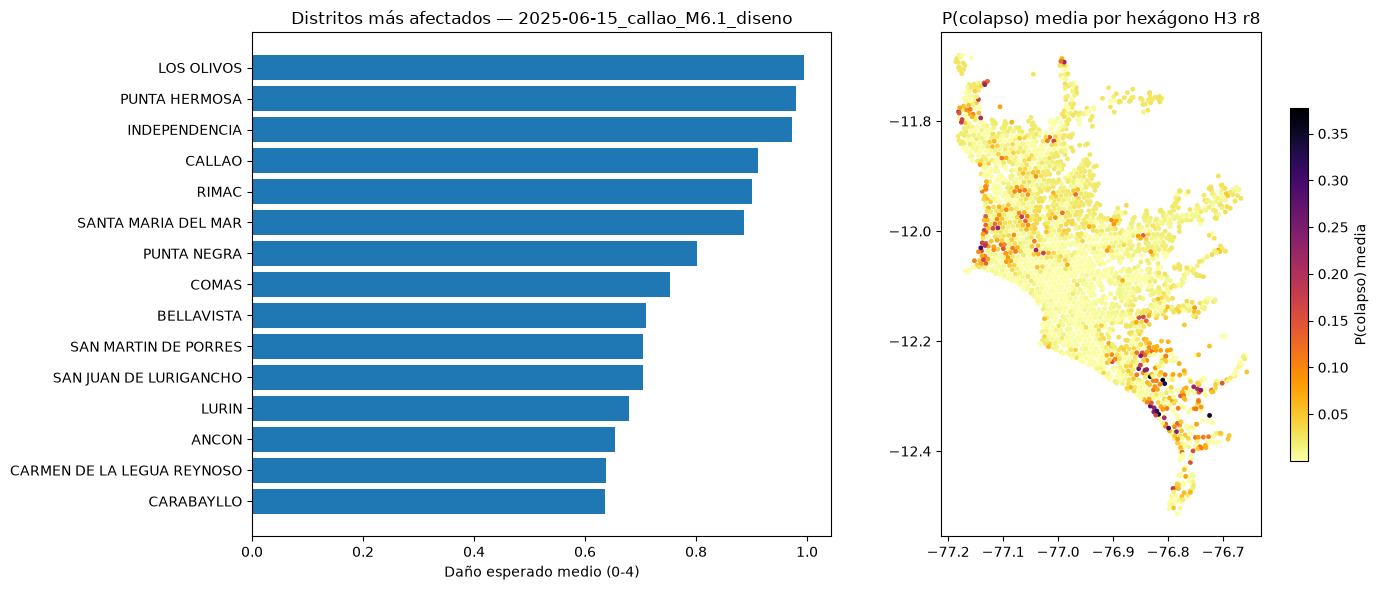

Tiempo total gold: 3.2 min


In [26]:
UMBRAL_COLAPSO = 0.10


def metricas_riesgo(df, claves):
    return df.groupBy(*claves).agg(
        F.count("*").alias("edificios"),
        F.expr("percentile_approx(Sa_Tb, 0.5)").alias("Sa_Tb_mediana_g"),
        F.avg("P_colapso").alias("P_colapso_media"),
        (100 * F.avg((F.col("P_colapso") > UMBRAL_COLAPSO).cast("double"))).alias("pct_P_colapso_mayor_umbral"),
        F.avg("dano_esperado").alias("dano_esperado_medio"),
        (100 * F.avg((F.abs(F.col("Tb_TP") - 1) < 0.2).cast("double"))).alias("pct_resonancia"),
        F.avg("vs30").alias("vs30_medio"), F.avg("pisos").alias("pisos_medio"))


ranking = (metricas_riesgo(de, ["escenario", "evento", "tipo", "ubigeo", "distrito", "provincia"])
           .withColumn("ranking", F.rank().over(Window.partitionBy("escenario").orderBy(F.desc("dano_esperado_medio")))))
escribir_delta(ranking, GOLD, "ranking_distritos")

centros_h3 = leer(SILVER, "edificios").groupBy("h3_r8").agg(F.avg("lon").alias("lon"), F.avg("lat").alias("lat"))
escribir_delta(metricas_riesgo(de, ["escenario", "evento", "tipo", "h3_r8"]).join(centros_h3, "h3_r8", "left"), GOLD, "riesgo_h3", particion="escenario")

ESCENARIO_VISTA = "2025-06-15_callao_M6.1_diseno"
rk = leer(GOLD, "ranking_distritos").where(F.col("escenario") == ESCENARIO_VISTA).orderBy("ranking").toPandas()
display(rk.head(10)[["ranking", "distrito", "provincia", "edificios", "Sa_Tb_mediana_g", "P_colapso_media",
                     "pct_P_colapso_mayor_umbral", "dano_esperado_medio", "pct_resonancia", "vs30_medio"]])

h3v = leer(GOLD, "riesgo_h3").where(F.col("escenario") == ESCENARIO_VISTA).toPandas()
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
top = rk.head(15).iloc[::-1]
ax[0].barh(top.distrito, top.dano_esperado_medio)
ax[0].set(xlabel="Daño esperado medio (0-4)", title=f"Distritos más afectados — {ESCENARIO_VISTA}")
sc = ax[1].scatter(h3v.lon, h3v.lat, c=h3v.P_colapso_media, s=6, cmap="inferno_r")
plt.colorbar(sc, ax=ax[1], shrink=.7, label="P(colapso) media")
ax[1].set_title("P(colapso) media por hexágono H3 r8"); ax[1].set_aspect("equal")
plt.tight_layout(); plt.show()
print(f"Tiempo total gold: {(time.perf_counter()-INICIO)/60:,.1f} min")

# Parte 6 · Modelos — detector de onda P (STEAD, paso 8)

Base del tiempo real: un clasificador que decide si una ventana de 4 s (3 componentes, 100 Hz) contiene la llegada de la onda P.

- **Datos:** muestra aleatoria de `silver.stead_trazas`; las ondas se leen del HDF5 local (no se sube).
- **Ejemplos:** por traza, una ventana **positiva** que contiene la P (de 1 s antes a 3 s después) y una **negativa** de ruido previo (de 5 s a 1 s antes de la P). Así se resuelve que `chunk2` solo traiga sismos.
- **Rasgos por ventana:** energía, máximo, curtosis y cociente de energía entre mitades (tipo STA/LTA) de cada componente; frecuencia dominante y relación Z/H.
- **Modelo:** Gradient Boosting (`HistGradientBoostingClassifier`), partición 75/25 **por traza**. Métricas: precisión, recall, F1 y AUC.
- **Línea base de llegada:** picador clásico STA/LTA (0.5 s / 5 s, umbral 4) en la componente Z → error en segundos frente a la P etiquetada.

Pendiente (fuera de este notebook): productor Kafka + Spark Structured Streaming que aplique este detector en ventanas deslizantes, U-Net siamesa con `xbd_escenas` → pares Maxar (requiere GPU) y dashboard (Streamlit + Kepler.gl) sobre `gold.riesgo_h3`, `gold.ranking_distritos` y `gold.dano_edificios`.

In [27]:
import h5py
from scipy.stats import kurtosis
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

N_TRAZAS = 10_000
FS_STEAD = 100
ANTES, DESPUES = 100, 300                  # ventana positiva: [P - 1 s, P + 3 s)


def rasgos_ventana(x):
    """x: (400, 3) E-N-Z. Rasgos de la ventana."""
    x = x - x.mean(0)
    mitad = len(x) // 2
    e1 = (x[:mitad] ** 2).mean(0) + 1e-12
    e2 = (x[mitad:] ** 2).mean(0) + 1e-12
    r = {}
    for i, c in enumerate("enz"):
        r[f"log_energia_{c}"] = float(np.log10((x[:, i] ** 2).mean() + 1e-12))
        r[f"log_max_{c}"] = float(np.log10(np.abs(x[:, i]).max() + 1e-12))
        r[f"curtosis_{c}"] = float(kurtosis(x[:, i]))
        r[f"log_ratio_mitades_{c}"] = float(np.log10(e2[i] / e1[i]))
    espectro = np.abs(np.fft.rfft(x[:, 2]))
    r["frec_dominante_z"] = float(np.fft.rfftfreq(len(x), 1 / FS_STEAD)[espectro.argmax()])
    r["log_z_sobre_h"] = float(np.log10(((x[:, 2] ** 2).mean() + 1e-12) / ((x[:, :2] ** 2).mean() + 1e-12)))
    return r


def picar_sta_lta(z, sta=50, lta=500, umbral=4.0):
    """Primer instante (s) en que STA/LTA supera el umbral; NaN si nunca."""
    z = z - z.mean()
    e = np.concatenate([[0.0], np.cumsum(z * z)])
    i = np.arange(lta, len(z) - sta)
    cociente = ((e[i + sta] - e[i]) / sta) / ((e[i] - e[i - lta]) / lta + 1e-20)
    sobre = np.nonzero(cociente > umbral)[0]
    return (i[sobre[0]] + sta) / FS_STEAD if sobre.size else np.nan


t0 = time.perf_counter()
trazas = (leer(SILVER, "stead_trazas")
          .where(f"p_arrival_sample >= {ANTES + 500} AND p_arrival_sample <= {6000 - DESPUES}")
          .select("trace_name", "p_arrival_sample", "source_magnitude", "source_distance_km", "_archivo_hdf5")
          .orderBy(F.rand(1)).limit(N_TRAZAS).toPandas())
archivo_hdf5 = Path(trazas["_archivo_hdf5"].iloc[0])
filas, picks = [], []
with h5py.File(archivo_hdf5, "r") as h:
    for r in trazas.to_dict("records"):
        x = np.asarray(h["data"][r["trace_name"]], dtype="float64")       # (6000, 3)
        p = int(r["p_arrival_sample"])
        filas.append({"trace_name": r["trace_name"], "etiqueta": 1, **rasgos_ventana(x[p - ANTES: p + DESPUES])})
        filas.append({"trace_name": r["trace_name"], "etiqueta": 0, **rasgos_ventana(x[p - ANTES - 400: p - ANTES])})
        picks.append({"trace_name": r["trace_name"], "p_s": p / FS_STEAD, "pick_sta_lta_s": picar_sta_lta(x[:, 2]),
                      "magnitud": r["source_magnitude"], "distancia_km": r["source_distance_km"]})
ventanas = pd.DataFrame(filas)
picks = pd.DataFrame(picks)
picks["error_s"] = picks.pick_sta_lta_s - picks.p_s
print(f"{len(trazas):,} trazas leídas de {archivo_hdf5.name} en {time.perf_counter()-t0:,.0f} s")

# Partición por traza (las dos ventanas de una traza quedan en el mismo conjunto)
rng = np.random.default_rng(1)
prueba = set(rng.choice(trazas.trace_name.unique(), size=len(trazas) // 4, replace=False))
ventanas["conjunto"] = np.where(ventanas.trace_name.isin(prueba), "prueba", "entreno")
RASGOS_P = [c for c in ventanas.columns if c not in ("trace_name", "etiqueta", "conjunto")]
ent, pru = ventanas[ventanas.conjunto == "entreno"], ventanas[ventanas.conjunto == "prueba"]
PARAMS_GBT = dict(max_iter=300, learning_rate=0.1, random_state=1)
gbt = HistGradientBoostingClassifier(**PARAMS_GBT).fit(ent[RASGOS_P], ent.etiqueta)
ventanas["prob_onda_p"] = gbt.predict_proba(ventanas[RASGOS_P])[:, 1]
pred = (ventanas.loc[pru.index, "prob_onda_p"] >= 0.5).astype(int)
registrar_modelo("detector_onda_p_gbt", PARAMS_GBT | {"trazas": len(trazas), "ventana_s": (ANTES + DESPUES) / FS_STEAD},
                 {"precision": precision_score(pru.etiqueta, pred), "recall": recall_score(pru.etiqueta, pred),
                  "f1": f1_score(pru.etiqueta, pred), "auc": roc_auc_score(pru.etiqueta, ventanas.loc[pru.index, "prob_onda_p"])}, gbt)
detectadas = picks.error_s.notna()
registrar_modelo("picador_sta_lta", {"sta_s": 0.5, "lta_s": 5.0, "umbral": 4.0},
                 {"pct_trazas_detectadas": 100 * detectadas.mean(),
                  "error_abs_mediano_s": picks.error_s.abs().median(),
                  "pct_error_menor_0_5s": 100 * (picks.error_s.abs() < 0.5).sum() / max(detectadas.sum(), 1)})

subir_pandas(ventanas, GOLD, "stead_ventanas")
subir_pandas(picks, GOLD, "stead_picks")

10,000 trazas leídas de chunk2.hdf5 en 70 s


  detector_onda_p_gbt: precision = 0.9645 | recall = 0.9680 | f1 = 0.9663 | auc = 0.9934
  picador_sta_lta: pct_trazas_detectadas = 99.8200 | error_abs_mediano_s = 0.0700 | pct_error_menor_0_5s = 90.1523


  ✓ gold.stead_ventanas: 20,000 filas (1 lote)                    


  ✓ gold.stead_picks: 10,000 filas (1 lote)                    


10000

## Métricas de todos los modelos → `gold.metricas_modelos`

In [28]:
metricas = pd.DataFrame(METRICAS)
metricas["fecha"] = datetime.now().isoformat(timespec="seconds")
subir_pandas(metricas, GOLD, "metricas_modelos")
display(metricas)

  ✓ gold.metricas_modelos: 17 filas (1 lote)                    


,modelo,metrica,valor,fecha
0,amplificacion_random_forest,rmse_lnF_loeo,0.461357,2026-10-08T22:05:00
1,amplificacion_random_forest,rmse_base_loeo,0.628489,2026-10-08T22:05:00
2,amplificacion_random_forest,filas_entreno,6850.000000,2026-10-08T22:05:00
3,perfiles_riesgo_kmeans,silueta,0.324318,2026-10-08T22:05:00
4,perfiles_riesgo_kmeans,silueta_k3,0.290340,2026-10-08T22:05:00
5,perfiles_riesgo_kmeans,silueta_k4,0.302796,2026-10-08T22:05:00
6,perfiles_riesgo_kmeans,silueta_k5,0.315181,2026-10-08T22:05:00
7,perfiles_riesgo_kmeans,silueta_k6,0.309169,2026-10-08T22:05:00
8,perfiles_riesgo_kmeans,silueta_k7,0.313002,2026-10-08T22:05:00
9,perfiles_riesgo_kmeans,silueta_k8,0.324318,2026-10-08T22:05:00


# Resumen final del lakehouse

In [70]:
display(inventario(BRONZE))
display(inventario(SILVER))
display(inventario(GOLD))
display(leer(SILVER, "calidad_log").groupBy("tabla", "regla", "accion")
        .agg(F.sum("n_filas").alias("filas")).orderBy("tabla", "accion").toPandas())

,tabla,filas,mb
0,bronze.cismid_registros,137,66.2
1,bronze.e030_factor_suelo,16,0.0
2,bronze.e030_perfiles,4,0.0
3,bronze.e030_zonas,4,0.0
4,bronze.limites_inei,1834,0.3
5,bronze.maxar_catalogo,2115,0.1
6,bronze.maxar_imagenes,10,0.0
7,bronze.microzonificacion_paginas,148,0.1
8,bronze.open_buildings,7219950,698.3
9,bronze.open_buildings_25d_teselas,44,0.0


,tabla,filas,mb
0,silver.calidad_log,1356762,9.3
1,silver.distritos,49,0.0
2,silver.e030_parametros,4,0.0
3,silver.edificios,1921174,238.5
4,silver.espectros,27400,0.2
5,silver.eventos,5,0.0
6,silver.maxar_pares,5,0.0
7,silver.microzonificacion_periodos,23,0.0
8,silver.microzonificacion_zonas,17,0.0
9,silver.ondas_registros,137,0.3


,tabla,filas,mb
0,gold.amplificacion_lima,4300,0.1
1,gold.dano_edificios,19211740,518.0
2,gold.demanda,19211740,353.6
3,gold.escenarios,10,0.0
4,gold.fragilidad_parametros,3,0.0
5,gold.metricas_modelos,17,0.0
6,gold.perfiles_riesgo,4,0.0
7,gold.ranking_distritos,470,0.0
8,gold.riesgo_h3,21930,1.5
9,gold.sa_roca_h3,21930,8.5


,tabla,regla,accion,filas
0,edificios,id_duplicado,descartado,2
1,edificios,confianza<0.75,descartado,1203720
2,edificios,fuera_del_rectangulo_lima,fuera_de_alcance,4021505
3,edificios,fuera_de_distritos_lima_callao,fuera_de_alcance,73549
4,edificios,sin_altura_2.5D,imputado,152103
5,suelo,vs30_nulo,descartado,0
6,suelo,pixel_fuera_de_lima_callao,fuera_de_alcance,6747
7,xbd_escenas,escena_sin_edificios,advertencia,934


### Árbol del catálogo en Databricks

In [71]:
from collections import defaultdict

cat_uc = CATALOG.lower()
objetos = spark.sql(f"""
    SELECT table_schema AS sch, table_name AS name, table_type AS tipo
    FROM system.information_schema.tables
    WHERE table_catalog = '{cat_uc}' AND table_schema <> 'information_schema'
    UNION ALL
    SELECT volume_schema AS sch, volume_name AS name, 'VOLUME' AS tipo
    FROM system.information_schema.volumes
    WHERE volume_catalog = '{cat_uc}'
""").collect()

arbol = defaultdict(list)
for r in objetos:
    arbol[r.sch].append((r.name, r.tipo))
iconos = {"MANAGED": "📄", "EXTERNAL": "🔗", "VIEW": "👁 ", "MATERIALIZED_VIEW": "👁 ", "STREAMING_TABLE": "🌊", "VOLUME": "📁"}

print(f"🗄  {cat_uc}")
esquemas = sorted(arbol)
for j, sch in enumerate(esquemas):
    ultimo_sch = j == len(esquemas) - 1
    print(f"{'└──' if ultimo_sch else '├──'} 📂 {sch}")
    items = sorted(arbol[sch])
    for k, (name, tipo) in enumerate(items):
        pref = "    " if ultimo_sch else "│   "
        rama = "└──" if k == len(items) - 1 else "├──"
        print(f"{pref}{rama} {iconos.get(tipo, '•')} {name}  ({tipo.lower()})")

🗄  grupo06proyectofinal
├── 📂 bronze
│   ├── 📄 cismid_registros  (managed)
│   ├── 📄 e030_factor_suelo  (managed)
│   ├── 📄 e030_perfiles  (managed)
│   ├── 📄 e030_zonas  (managed)
│   ├── 📄 limites_inei  (managed)
│   ├── 📄 maxar_catalogo  (managed)
│   ├── 📄 maxar_imagenes  (managed)
│   ├── 📄 microzonificacion_paginas  (managed)
│   ├── 📄 open_buildings  (managed)
│   ├── 📄 open_buildings_25d_teselas  (managed)
│   ├── 📄 shakemap_grid  (managed)
│   ├── 📄 stead_metadata  (managed)
│   ├── 📁 volumen01  (volume)
│   ├── 📄 vs30_pixeles  (managed)
│   └── 📄 xbd_indice  (managed)
├── 📂 gold
│   ├── 📄 amplificacion_lima  (managed)
│   ├── 📄 dano_edificios  (managed)
│   ├── 📄 demanda  (managed)
│   ├── 📄 escenarios  (managed)
│   ├── 📄 fragilidad_parametros  (managed)
│   ├── 📄 metricas_modelos  (managed)
│   ├── 📄 perfiles_riesgo  (managed)
│   ├── 📄 ranking_distritos  (managed)
│   ├── 📄 riesgo_h3  (managed)
│   ├── 📄 sa_roca_h3  (managed)
│   ├── 📄 stead_picks  (managed)
│   └── 📄 stea

## Limpieza opcional
Borra **todo** el catálogo del proyecto (tablas y volumen). Solo se ejecuta si `confirmacion = "BORRAR CATALOGO"`.

In [72]:
catalogo_borrar = CATALOG
confirmacion = "BORRAR CATALOGO"
if confirmacion == "BORRAR CATALOGO":
    spark.sql(f"DROP CATALOG IF EXISTS `{catalogo_borrar}` CASCADE")
    print(f"Catalogo eliminado: {catalogo_borrar}")
else:
    print("Limpieza no ejecutada")

C:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyspark\sql\connect\client\core.py:2319: UserWarning: Spark Connect Session expired on the server. Please generate a new session by detaching and reattaching the compute or by calling DatabricksSession.builder.getOrCreate().
  warnings.warn(
C:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyspark\sql\connect\client\reattach.py:255: UserWarning: ReleaseExecute failed with exception: <_InactiveRpcError of RPC that terminated with:
	status = StatusCode.FAILED_PRECONDITION
	details = "BAD_REQUEST: session_id is no longer usable. Generate a new session_id by detaching and reattaching the compute and then try again [sessionId=b55642c3-4626-433f-b9e5-84a76604cec1, reason=INACTIVITY_TIMEOUT_AND_FAILED_TO_RESTORE].  (requestId=b71d21f3-2bef-4249-933c-41888346cdfa)"
	debug_error_string = "FAILED_PRECONDITION:BAD_REQUEST: session_id is no longer usable. Generate a new session_id by detaching and reat

SparkConnectGrpcException: () BAD_REQUEST: session_id is no longer usable. Generate a new session_id by detaching and reattaching the compute and then try again [sessionId=b55642c3-4626-433f-b9e5-84a76604cec1, reason=INACTIVITY_TIMEOUT_AND_FAILED_TO_RESTORE].  (requestId=79cea706-7206-4137-9a31-3ab1029403a5)